**1.Credit Card Default Prediction
Predict whether a customer will default on credit card payments.**

**1.1 Explore the data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()


Saving default_of_credit_card_clients.xls to default_of_credit_card_clients.xls


In [ ]:
df = pd.read_excel("default_of_credit_card_clients.xls", header=1)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
df = df.drop("ID", axis=1)

In [ ]:
df.shape
df.info()
df.isnull().sum()
df['default payment next month'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_A

,count
default payment next month,
0,23364
1,6636


**Distributions**

Categorical Variables

(SEX, EDUCATION, MARRIAGE, DEFAULT)

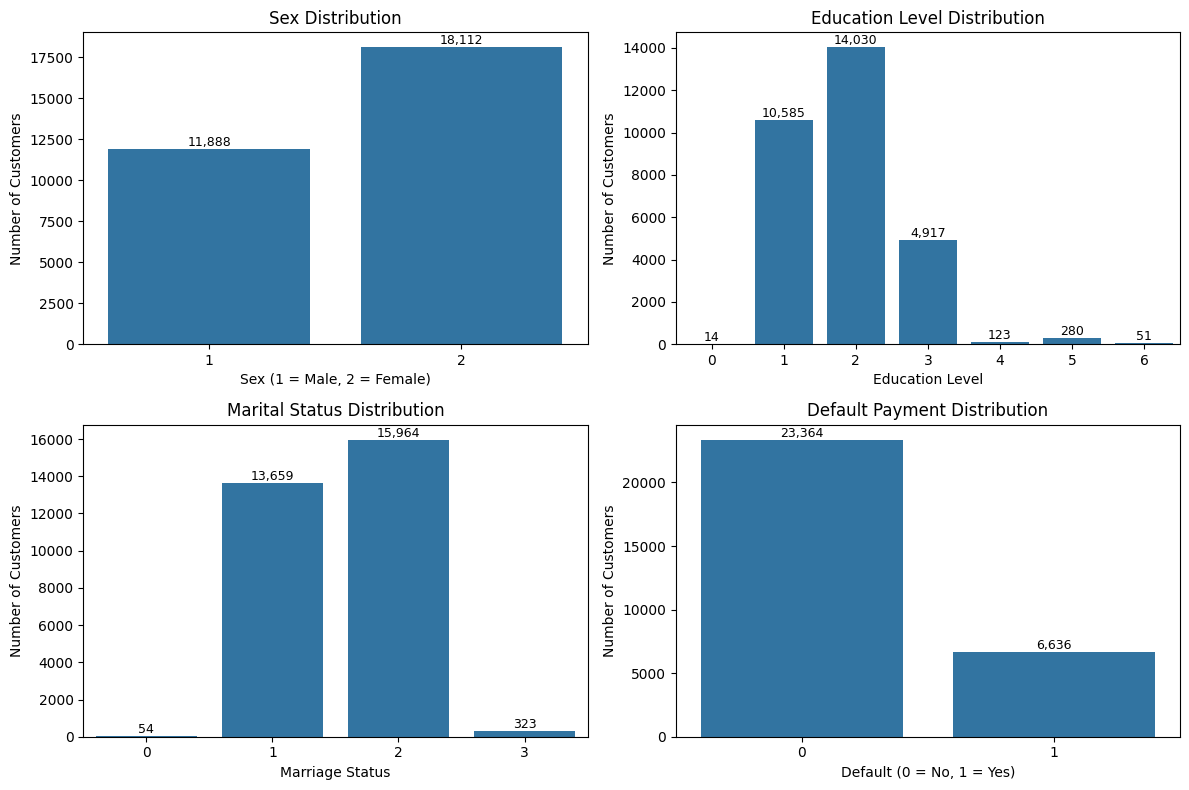

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(12,8))

sns.countplot(x='SEX', data=df, ax=ax[0,0])
ax[0,0].set_title("Sex Distribution")
ax[0,0].set_xlabel("Sex (1 = Male, 2 = Female)")
ax[0,0].set_ylabel("Number of Customers")

sns.countplot(x='EDUCATION', data=df, ax=ax[0,1])
ax[0,1].set_title("Education Level Distribution")
ax[0,1].set_xlabel("Education Level")
ax[0,1].set_ylabel("Number of Customers")

sns.countplot(x='MARRIAGE', data=df, ax=ax[1,0])
ax[1,0].set_title("Marital Status Distribution")
ax[1,0].set_xlabel("Marriage Status")
ax[1,0].set_ylabel("Number of Customers")

sns.countplot(x='default payment next month', data=df, ax=ax[1,1])
ax[1,1].set_title("Default Payment Distribution")
ax[1,1].set_xlabel("Default (0 = No, 1 = Yes)")
ax[1,1].set_ylabel("Number of Customers")
# Add values on top of each bar (for all subplots)
for i in range(2):
    for j in range(2):
        for p in ax[i, j].patches:
            ax[i, j].annotate(f'{int(p.get_height()):,}',
                              (p.get_x() + p.get_width()/2., p.get_height()),
                              ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Observation:
Most customers are well educated belonging to university (category 1)  and graduate (category 2) levels.
Very few belong to "other/unknown" and may not contribute much. Further, most customers are single or married, higher numbers are single belongingto category 2.
The dataset shows imbalance in the target variable which is default payment distribution, with significantly more non-default cases (category 0)than default cases (category 1). Categorical variables contain uneven category distributions, which may affect model learning.
This is a classification problem with class imbalance


Credit Limit and Age

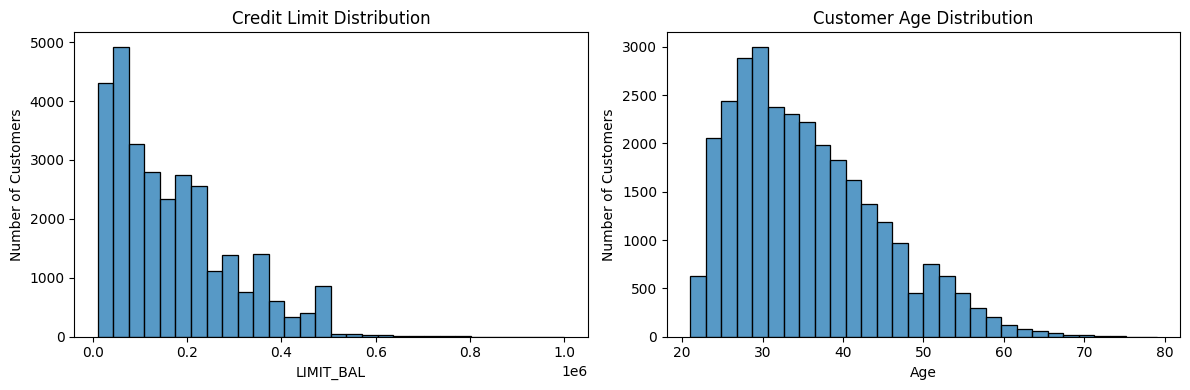

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

sns.histplot(df['LIMIT_BAL'], bins=30, ax=ax[0])
ax[0].set_title("Credit Limit Distribution")
ax[0].set_xlabel("LIMIT_BAL")
ax[0].set_ylabel("Number of Customers")

sns.histplot(df['AGE'], bins=30, ax=ax[1])
ax[1].set_title("Customer Age Distribution")
ax[1].set_xlabel("Age")
ax[1].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()



Observation:
The credit limit (LIMIT_BAL) shows a right-skewed distribution, with most customers having relatively low credit limits and a few customers having very high limits. This indicates the presence of outliers and non-normal distribution. Also, the age distribution is approximately bell-shaped, with most customers between 25-45 years. However, it is slightly right-skewed so we can comment that majority customers are of working-age population

This suggests that preprocessing techniques such as scaling or transformation may be required before training the model.

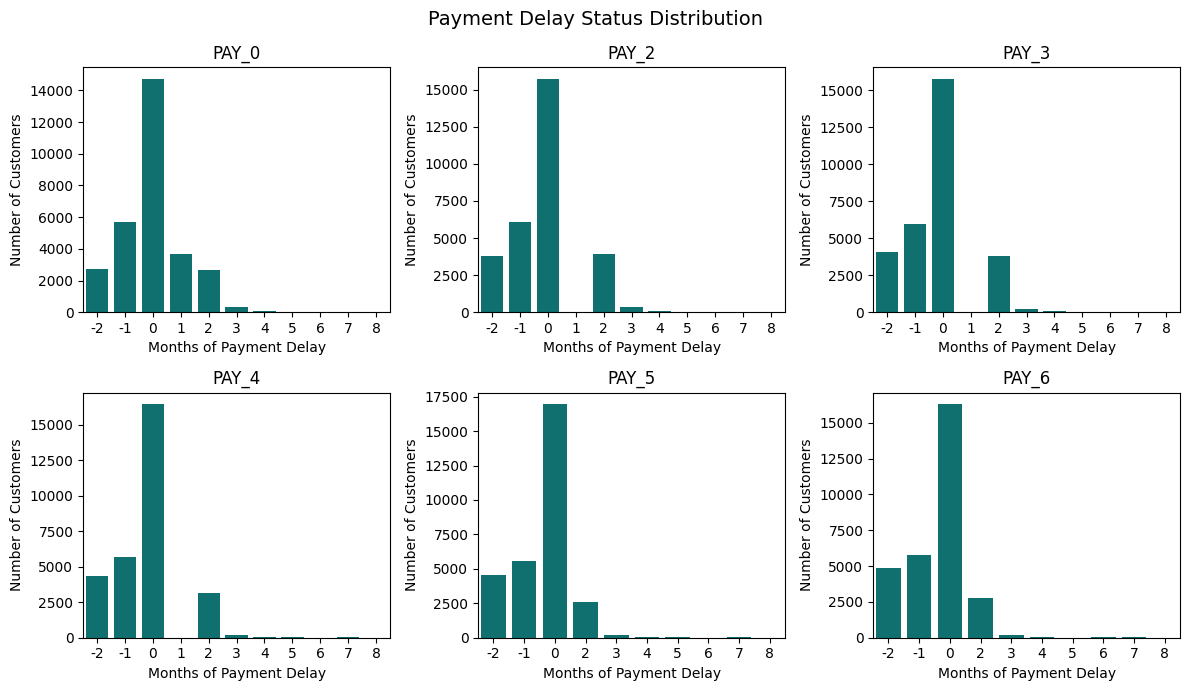

In [ ]:
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

fig, axes = plt.subplots(2, 3, figsize=(12,7))

for i, col in enumerate(pay_cols):
    ax = axes[i//3, i%3]

    sns.countplot(x=df[col], ax=ax, color='teal')

    ax.set_title(col)
    ax.set_xlabel("Months of Payment Delay")
    ax.set_ylabel("Number of Customers")

plt.suptitle("Payment Delay Status Distribution", fontsize=14)
plt.tight_layout()
plt.show()


Observation:
As observed high frequency of values 0, -1, and -2 across all PAY variables, most customers have no payment delay or they pay early. The distribution is highly right-skewed, with very few customers having large payment delays (greater than 3 months). Such consistent pattern is observed across all six months, which suggests stable repayment behavior over time.
So, customers with no delay (0, -1, -2) are less likely to default, while those with increasing delays (1, 2, 3 months and above) show a higher likelihood of default. Since these variables reflect recent repayment behavior, they are expected to be among the most important predictors in the model.


Bill Amount Distribution

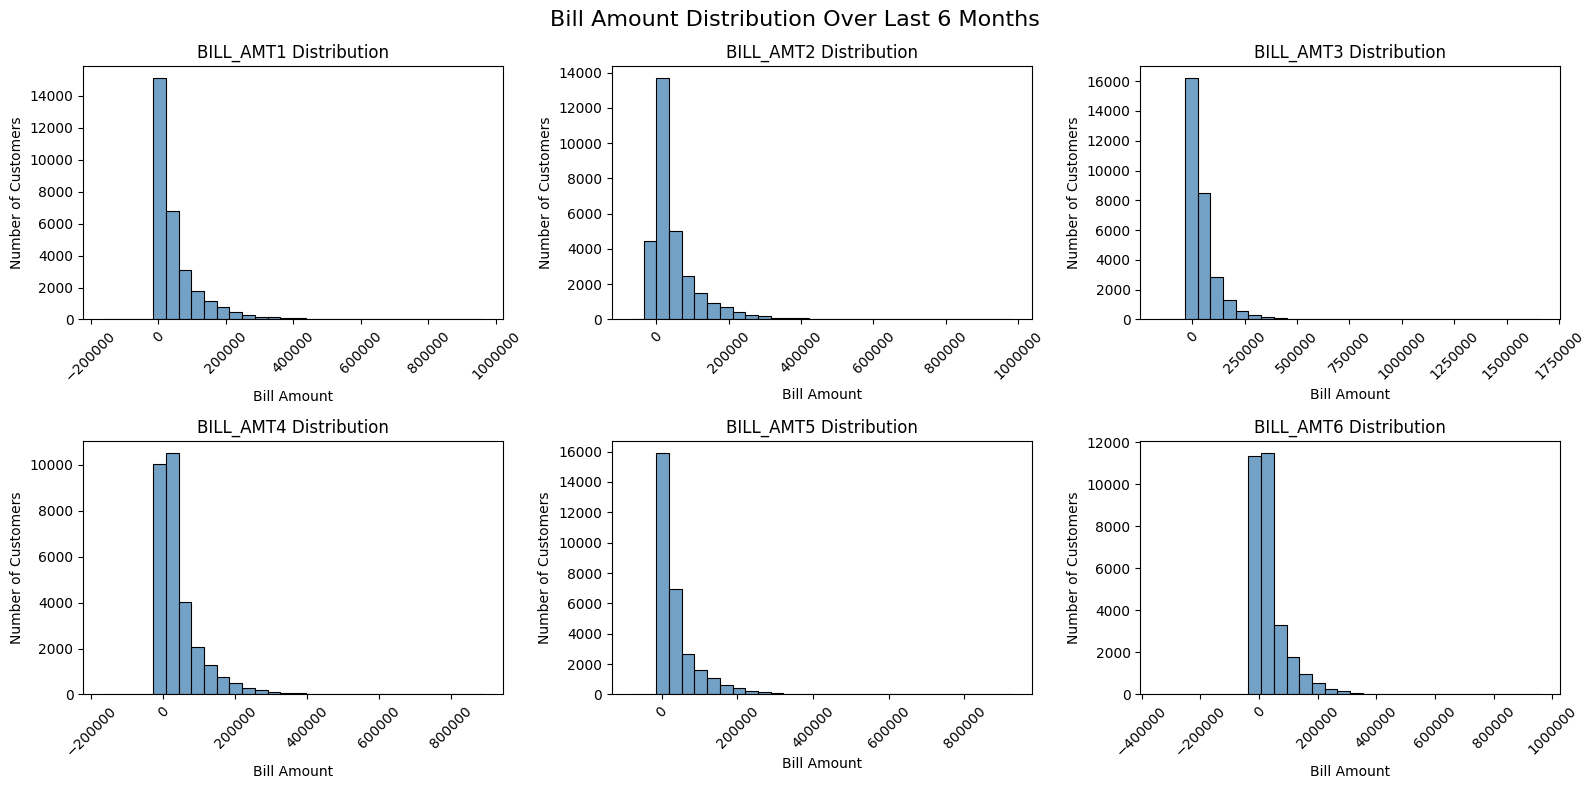

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']

fig, axes = plt.subplots(2,3, figsize=(16,8))

for i, col in enumerate(bill_cols):

    ax = axes[i//3, i%3]

    sns.histplot(df[col], bins=30, ax=ax, color='steelblue')

    ax.set_title(f"{col} Distribution")
    ax.set_xlabel("Bill Amount")
    ax.set_ylabel("Number of Customers")

    # force normal number format
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.ticklabel_format(style='plain', axis='x')

    ax.tick_params(axis='x', rotation=45)

plt.suptitle("Bill Amount Distribution Over Last 6 Months", fontsize=16)

plt.tight_layout()
plt.show()

Observation:
The bill amount variables (BILL_AMT1 to BILL_AMT6) show highly right-skewed distributions, with most customers having low to moderate bill amounts and a few having very high values. The presence of extreme values indicates outliers, and negative values may represent overpayments. A consistent distribution pattern across all six months suggests stable billing behavior over time. Again, these variables are not normally distributed and may require preprocessing. On the other hand, higher bill amounts may indicate increased financial burden and potential risk of default.

Payment Amount Distribution

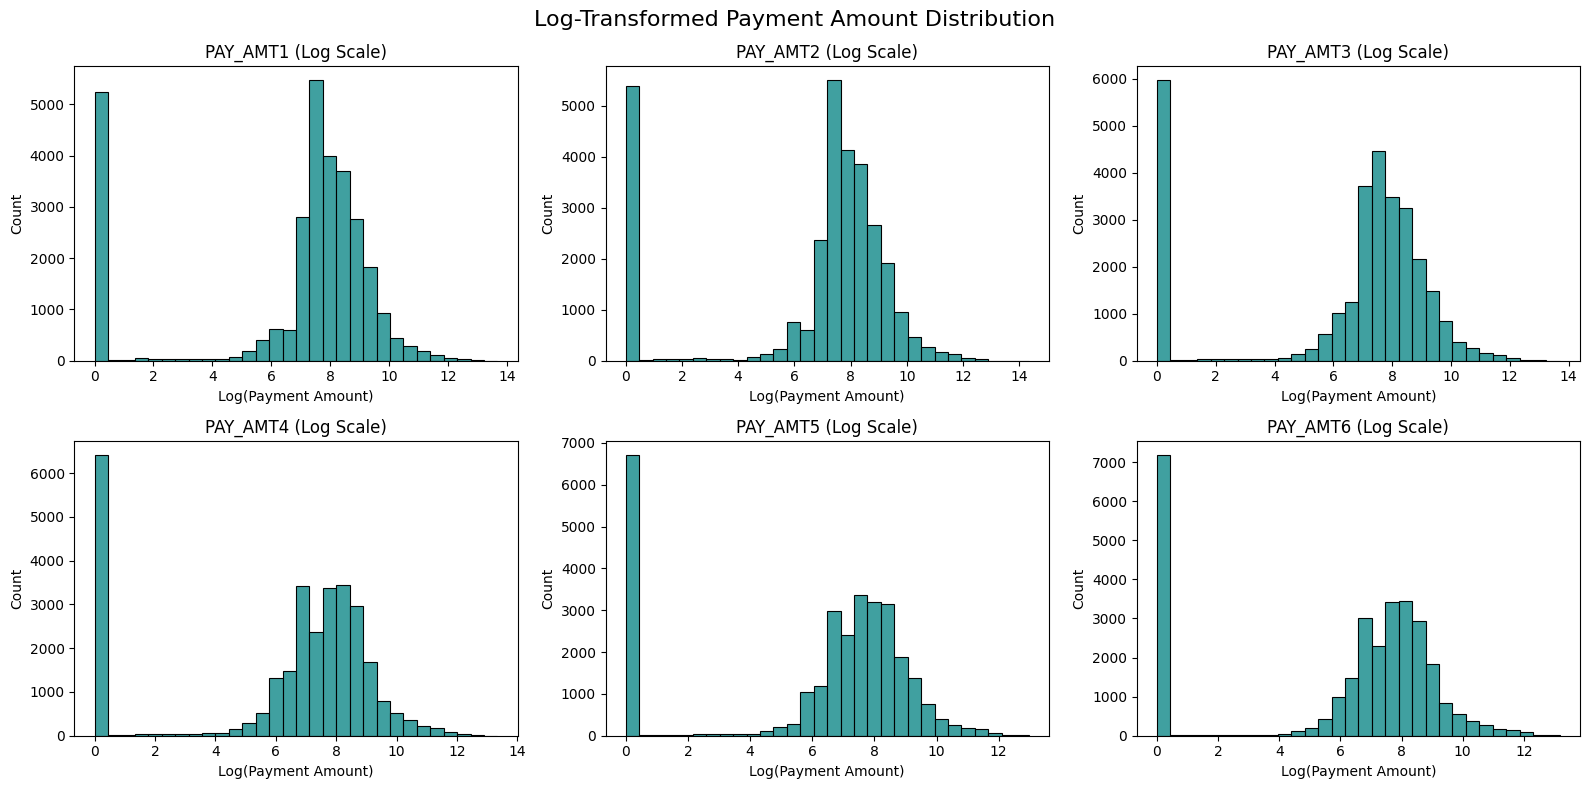

In [ ]:
import numpy as np

pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']

fig, axes = plt.subplots(2, 3, figsize=(16,8))

for i, col in enumerate(pay_amt_cols):
    ax = axes[i//3, i%3]

    # apply log transform (important!)
    data = np.log1p(df[col])   # log(1 + x)

    sns.histplot(data, bins=30, ax=ax, color='teal')

    ax.set_title(f"{col} (Log Scale)")
    ax.set_xlabel("Log(Payment Amount)")
    ax.set_ylabel("Count")

plt.suptitle("Log-Transformed Payment Amount Distribution", fontsize=16)
plt.tight_layout()
plt.show()

Observation:
The payment variables were highly right-skewed, with most values close to zero and a few extreme outliers. To improve visualization, a log transformation (log(1 + x)) was applied. The transformed distributions appear more symmetric and reveal the underlying structure of the data. A larger number of customers had zero payments which indicates potential financial stress or default risk.

Moreover, most payment amounts fall within the log range of 4 to 6. This indicates that a majority of customers make low or partial payments rather than clearing full dues, which may contribute to increased default risk.

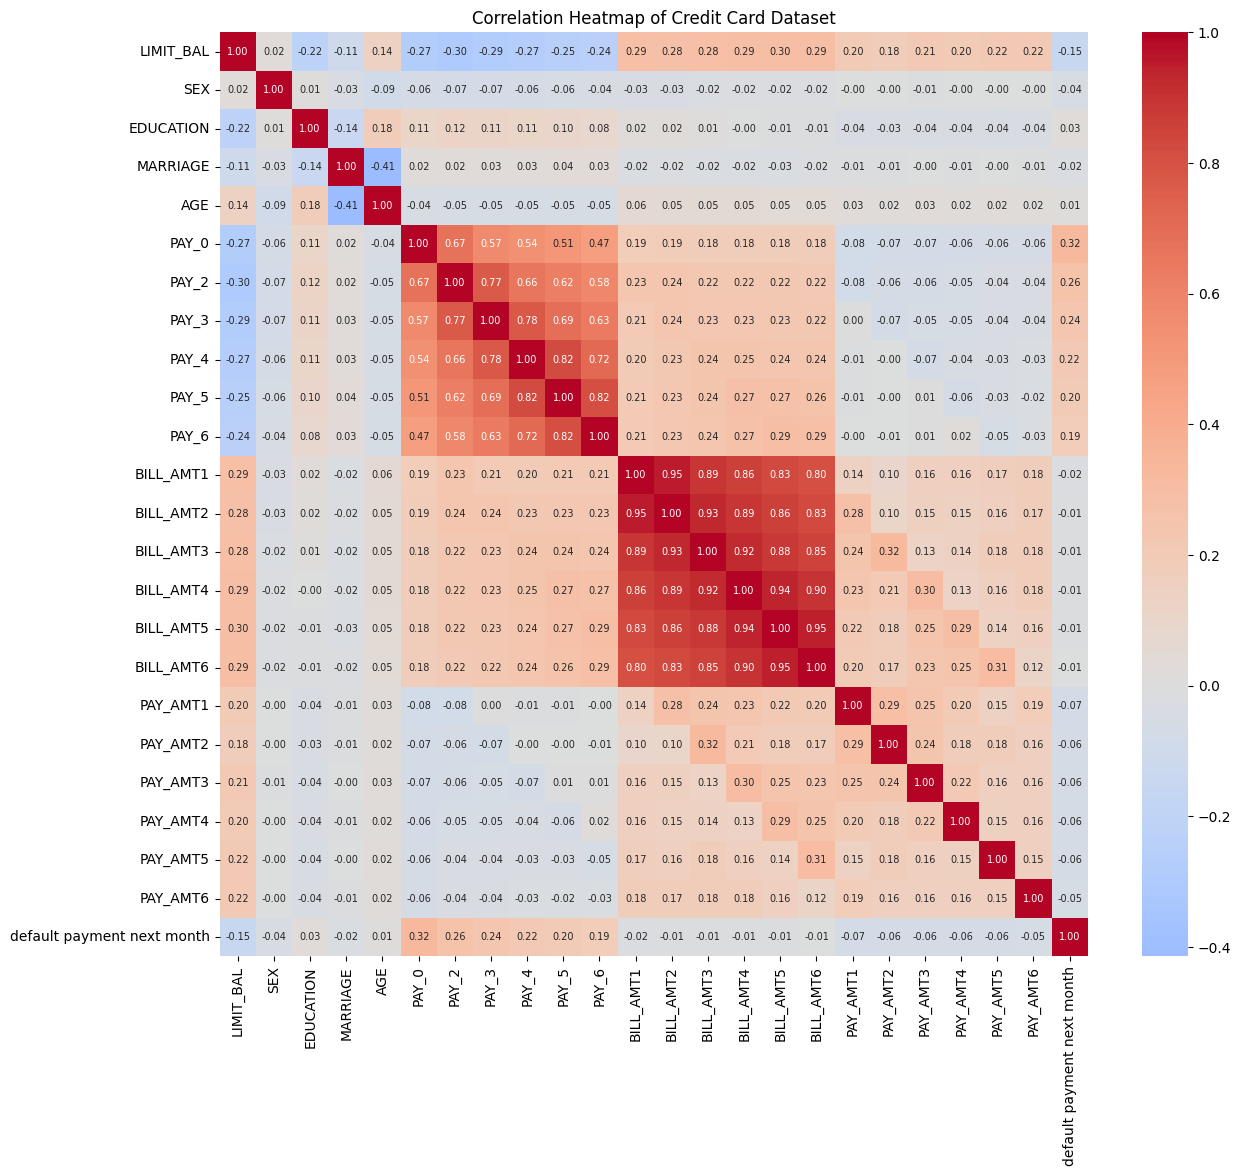

In [ ]:
plt.figure(figsize=(14, 12))

corr_matrix = df.corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            annot_kws={"size": 7})

plt.title("Correlation Heatmap of Credit Card Dataset")
plt.show()

Payment delay variables (PAY_0 to PAY_6) show the strongest positive correlation with default, which shows that customers with a history of delayed payments are more likely to default. In particular, PAY_0 shows the highest positive correlation with default, indicating that recent payment delays are strong predictors of default risk.
Bill amount variables are highly correlated among themselves, showing consistent credit usage patterns. If a customer has high bill amount in on emonth, it is likely that the customer will have higher bill amount in next months. Payment amount variables have weaker correlations. Other variables such demographic features (age, sex, education, marriage status) show weak or negligible associations with the default (target), which tells us they have limited role in prediction. Credit limit shows a slight negative correlation, suggesting that customers with higher limits are less likely to default.

Label distribution

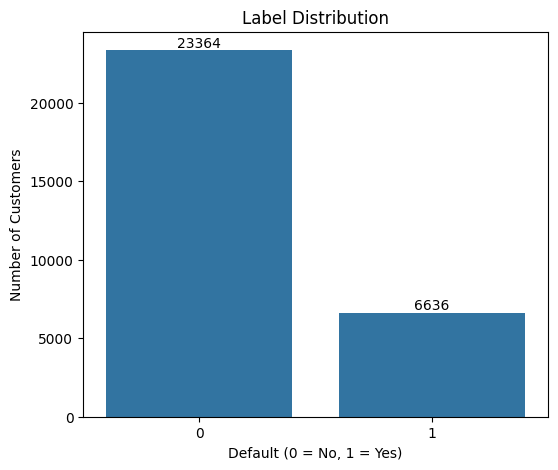

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

ax = sns.countplot(x='default payment next month', data=df)

plt.title("Label Distribution")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

# Add numbers on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.show()

Observation: The dataset shows imbalance in the target variable which is default payment distribution, with significantly more non-default cases (category 0)than default cases (category 1). Such imbalance can bias models toward the majority class, making accuracy an unreliable metric.

**Are there any strong associations between any input and output variable
that are immediately obvious?**

Payment delay variables (PAY_0 to PAY_6) show the strongest positive correlation with default, which shows that customers with a history of delayed payments are more likely to default. In particular, PAY_0 shows the highest positive correlation with default, indicating that recent payment delays are strong predictors of default risk.
Bill amount variables are highly correlated among themselves, showing consistent credit usage patterns. If a customer has high bill amount in on emonth, it is likely that the customer will have higher bill amount in next months. Payment amount variables have weaker correlations. Other variables such demographic features (age, sex, education, marriage status) show weak or negligible associations with the default (target), which tells us they have limited role in prediction. Credit limit shows a slight negative correlation, suggesting that customers with higher limits are less likely to default.

**What performance metrics should be used and why?**

The problem is a binary classification task aimed at predicting whether a customer will default on credit card payments. The dataset contains 30,000 samples and 24 features, including both numerical variables (such as LIMIT_BAL, AGE, BILL_AMT) and categorical variables (such as SEX, EDUCATION, MARRIAGE, and repayment status variables), all of which are integers.

There are no missing values in the dataset, indicating that it is clean and does not require imputation. The target variable is imbalanced, with approximately 78% non-default cases and 22% default cases. This imbalance suggests that accuracy alone may not be a reliable performance metric.


Since this is a binary classification problem with imbalanced classes, accuracy alone is not an appropriate metric. Precision, recall, and F1-score should be used to evaluate model performance. Recall is particularly important as it measures the model’s ability to correctly identify defaulters, minimizing false negatives which can lead to financial losses. Additionally, ROC-AUC can be used to evaluate the model’s ability to distinguish between default and non-default cases.

**Q 1.2 Data** **Transformation**

In [ ]:
#step 1: Seperate features and target
X = df.drop('default payment next month', axis=1)
y = df['default payment next month']

#step 2: Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
#step 3: Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (24000, 23)
Test set shape: (6000, 23)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)

X_train = pca.fit_transform(X_train_scaled)
X_test = pca.transform(X_test_scaled)

Data preprocessing was carried for separating features and target variables, followed by splitting the dataset into training and testing sets to ensure proper evaluation of our model. Feature scaling was applied using StandardScaler to normalize the data and prevent bias due to varying feature scales. Principal Component Analysis (PCA) was used to reduce dimensionality and remove redundancy among highly correlated features while preserving important variance. Overall, this improves computational efficiency and helps prevent overfitting.

In [ ]:
pd.DataFrame(X_train_scaled).head()

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,-0.672359,0.808159,0.184306,0.858114,-1.244658,0.014796,0.109694,0.141120,0.188700,0.234055,...,0.455707,0.479450,-0.008367,0.011698,-0.126892,-0.039537,-0.173567,-0.224654,-0.216008,-0.245240
1,-1.057768,-1.237381,0.184306,0.858114,-0.811521,0.014796,0.109694,0.141120,0.188700,0.234055,...,-0.254132,-0.277182,-0.299323,-0.653898,-0.038915,-0.194250,-0.241596,-0.240785,-0.308523,-0.295532
2,0.098459,0.808159,3.971420,-1.054828,0.921024,0.014796,0.109694,-0.698046,-0.667404,-0.648616,...,-0.662788,-0.671371,-0.548685,-0.479473,-0.331937,-0.210475,-0.288246,0.122676,0.353487,-0.285107
3,-0.826523,-1.237381,-1.078065,0.858114,-1.136374,0.014796,0.109694,0.141120,0.188700,0.234055,...,-0.118736,-0.052671,-0.008763,0.006350,-0.213815,-0.167236,-0.178610,-0.207358,-0.186877,-0.180973
4,-0.286950,0.808159,0.184306,0.858114,-1.136374,0.014796,0.109694,0.141120,0.188700,0.234055,...,0.981423,1.167654,1.330983,1.436224,-0.091947,-0.072522,-0.014157,0.007308,0.011598,0.317359


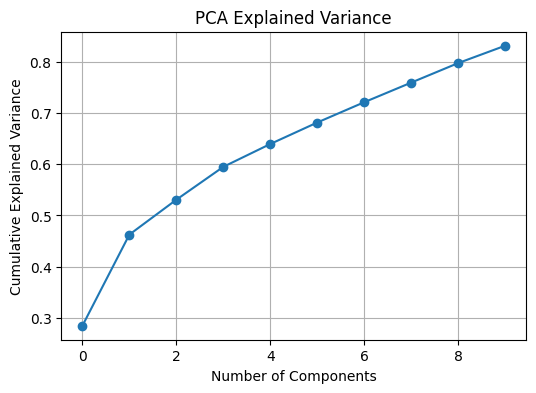

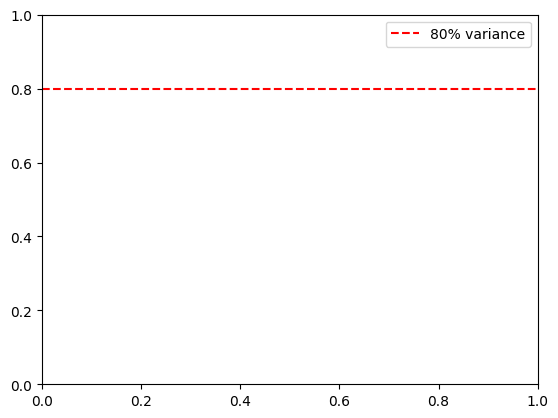

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(6,4))
plt.plot(cumulative_var, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()
plt.axhline(y=0.8, color='r', linestyle='--', label='80% variance')
plt.legend()

The PCA explained variance plot shows how much information is retained as the number of principal components increases. The cumulative variance increases rapidly for the first few components and begins to saturate after around 6-7 components. This indicates that most of the important information in the dataset is captured by a reduced number of components. Therefore, PCA effectively reduces dimensionality while preserving the majority of the variance, helping to remove redundancy and improve computational efficiency.

**Q1****.3** **ML** **model** **type**

 logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred_log)

0.81

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix


print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.69      0.24      0.35      1313

    accuracy                           0.81      6000
   macro avg       0.76      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000



The logistic regression model achieved an overall accuracy of 81%. However, due to class imbalance, the model performs significantly better for non-default cases (class 0) with high recall (0.97), while performing poorly for default cases (class 1) with low recall (0.24). This suggest that the model fails to identify a large proportion of defaulters, thus using accuracy is not much reliable metric. Therefore, metrics such as recall, precision, and F1-score are more appropriate for evaluating performance in this problem.

 simple SVM

In [ ]:
from sklearn.svm import SVC

svm_linear = SVC(kernel='linear')

svm_linear.fit(X_train_scaled, y_train)

y_pred_svm_linear = svm_linear.predict(X_test_scaled)

from sklearn.metrics import accuracy_score

print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_svm_linear))

Linear SVM Accuracy: 0.8105


In [ ]:
print(classification_report(y_test, y_pred_svm_linear))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.70      0.23      0.35      1313

    accuracy                           0.81      6000
   macro avg       0.76      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000



The linear SVM model achieved an accuracy of approximately 81%, similar to logistic regression. However, both models perform poorly in detecting default cases (class 1), low recall (0.24). This suggests that the models are biased toward the majority class due to class imbalance. Therefore, accuracy alone is not a reliable metric, and recall and F1-score should be considered.

RBF kernel SVM

In [ ]:
svm_rbf = SVC(kernel='rbf')

svm_rbf.fit(X_train_scaled, y_train)

y_pred_svm_rbf = svm_rbf.predict(X_test_scaled)

print("RBF SVM Accuracy:", accuracy_score(y_test, y_pred_svm_rbf))
print(classification_report(y_test, y_pred_svm_rbf))

RBF SVM Accuracy: 0.8193333333333334
              precision    recall  f1-score   support

           0       0.84      0.96      0.89      4687
           1       0.68      0.33      0.45      1313

    accuracy                           0.82      6000
   macro avg       0.76      0.64      0.67      6000
weighted avg       0.80      0.82      0.79      6000



RBF SVM improves recall for default class (0.33 vs 0.24), meaning it identifies more risky customers (defaulters), but performance is still limited.

Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.7206666666666667
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      4687
           1       0.37      0.40      0.39      1313

    accuracy                           0.72      6000
   macro avg       0.60      0.61      0.60      6000
weighted avg       0.73      0.72      0.72      6000



In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = {
    "Model": ["Logistic Regression", "Linear SVM", "RBF SVM", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_svm_linear),
        accuracy_score(y_test, y_pred_svm_rbf),
        accuracy_score(y_test, y_pred_tree)
    ],
    "Recall (Default=1)": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_svm_linear),
        recall_score(y_test, y_pred_svm_rbf),
        recall_score(y_test, y_pred_tree)
    ],
    "F1 Score (Default=1)": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_svm_linear),
        f1_score(y_test, y_pred_svm_rbf),
        f1_score(y_test, y_pred_tree)
    ]
}

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Recall (Default=1),F1 Score (Default=1)
0,Logistic Regression,0.810000,0.236862,0.353008
1,Linear SVM,0.810500,0.230769,0.347676
2,RBF SVM,0.819333,0.332064,0.445808
3,Decision Tree,0.720667,0.399848,0.385180


Although all models achieve almost similar accuracy (~80%) except decision tree (72%), this is still misleading due to class imbalance. The RBF SVM model performs slightly better in detecting defaulters, as seen from higher recall and F1-score for class 1. However, overall performance remains limited, which suggests the need for class balancing or threshold tuning.

ROC-AUC for all models

Step 1: Get probabilities

In [ ]:
# Logistic Regression
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

# Linear SVM
y_prob_svm_linear = svm_linear.decision_function(X_test_scaled)

# RBF SVM
y_prob_svm_rbf = svm_rbf.decision_function(X_test_scaled)

# Decision Tree
y_prob_tree = tree.predict_proba(X_test)[:, 1]

Step 2: Calculate ROC-AUC

In [ ]:
from sklearn.metrics import roc_auc_score

print("ROC-AUC Scores:")

print("Logistic Regression:", roc_auc_score(y_test, y_prob_log))
print("Linear SVM:", roc_auc_score(y_test, y_prob_svm_linear))
print("RBF SVM:", roc_auc_score(y_test, y_prob_svm_rbf))
print("Decision Tree:", roc_auc_score(y_test, y_prob_tree))

ROC-AUC Scores:
Logistic Regression: 0.7269867506354779
Linear SVM: 0.7112200117288978
RBF SVM: 0.7143238309979264
Decision Tree: 0.6052464636593478


The ROC-AUC scores confirm that Logistic Regression is the best-performing model, followed by RBF SVM and Linear SVM. All three models show moderate predictive ability (AUC between 0.70-0.73), while the Decision Tree performs significantly worse (AUC ~0.60). Since ROC-AUC is threshold-independent, it provides a reliable measure of model performance in this imbalanced dataset.

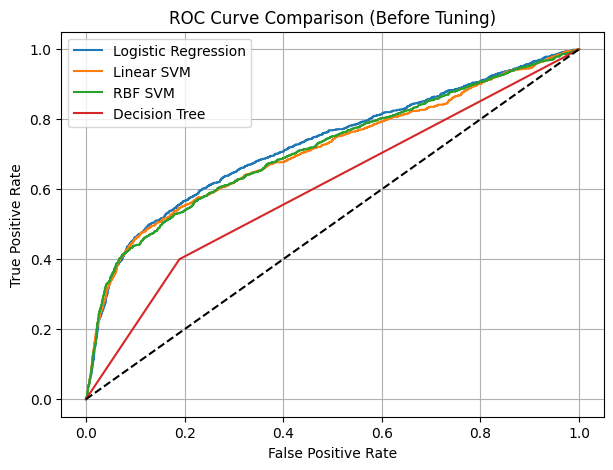

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Compute curves
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_lin, tpr_lin, _ = roc_curve(y_test, y_prob_svm_linear)
fpr_rbf, tpr_rbf, _ = roc_curve(y_test, y_prob_svm_rbf)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)

plt.figure(figsize=(7,5))

plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_lin, tpr_lin, label="Linear SVM")
plt.plot(fpr_rbf, tpr_rbf, label="RBF SVM")
plt.plot(fpr_tree, tpr_tree, label="Decision Tree")

plt.plot([0,1], [0,1], 'k--')  # baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Before Tuning)")
plt.legend()
plt.grid()

plt.show()

The ROC curve comparison shows that Logistic Regression achieves the best performance with the highest AUC (~0.73), closely followed by RBF SVM and Linear SVM. The Decision Tree performs poorly, with an AUC close to 0.6. The curves demonstrate that linear models provide better separation between classes than the decision tree.

Confusion matrix

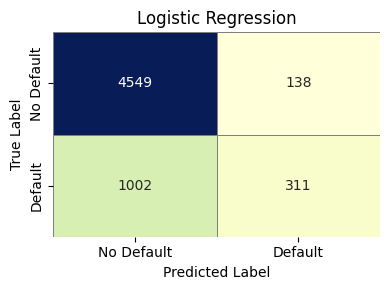

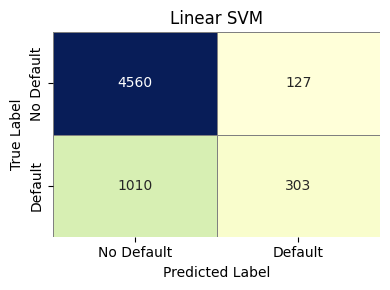

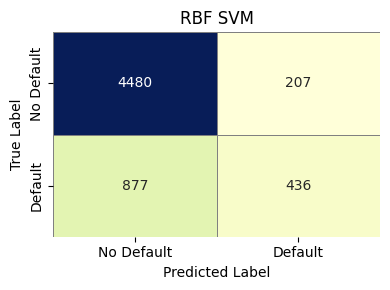

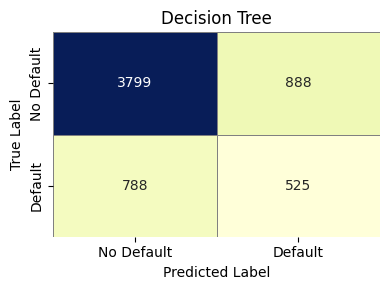

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Function to plot confusion matrix
def plot_cm(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='YlGnBu',
                cbar=False,
                linewidths=0.5,
                linecolor='gray',
                annot_kws={"size": 10},
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'])

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


# ---- Plot for all models ----
plot_cm(y_test, y_pred_log, "Logistic Regression")
plot_cm(y_test, y_pred_svm_linear, "Linear SVM")
plot_cm(y_test, y_pred_svm_rbf, "RBF SVM")
plot_cm(y_test, y_pred_tree, "Decision Tree")

The confusion matrices indicate that all models perform well in correctly classifying non-default customers (True Negatives), but struggle to identify default cases (True Positives). Logistic Regression and SVM models show high True Negative values but relatively high False Negatives, indicating low recall for the default class. In contrast, the Decision Tree detects more default cases (higher True Positives) but at the cost of increased False Positives. This is the challenge of class imbalance, where models tend to favor the majority class (non-default).

**After Hyperparameter tuninig**

Logistic regression

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid_log = {
    'C': [0.01, 0.1, 1, 10]
}

grid_log = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_log,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_log.fit(X_train_scaled, y_train)

print("Best parameters:", grid_log.best_params_)
print("Best CV score:", grid_log.best_score_)

Best parameters: {'C': 1}
Best CV score: 0.8099999999999999


In [ ]:
best_log = grid_log.best_estimator_

y_pred_log_tuned = best_log.predict(X_test_scaled)

print("Tuned Logistic Accuracy:", accuracy_score(y_test, y_pred_log_tuned))
print(classification_report(y_test, y_pred_log_tuned))

Tuned Logistic Accuracy: 0.81
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.69      0.24      0.35      1313

    accuracy                           0.81      6000
   macro avg       0.76      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000



Linear SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

#Step 1: Parameter grid (reduced for speed)
param_grid_svm_linear = {
    'C': [0.1, 1]   # small grid → faster
}

#Step 2: Grid Search (reduced CV)
grid_svm_linear = GridSearchCV(
    estimator=SVC(kernel='linear'),
    param_grid=param_grid_svm_linear,
    cv=3,                    # reduced folds
    scoring='accuracy',
    n_jobs=-1,              # use all CPU cores
    verbose=1
)

#Step 3: Fit model
grid_svm_linear.fit(X_train_scaled, y_train)

#Step 4: Best parameters
print("Best Parameters:", grid_svm_linear.best_params_)
print("Best CV Score:", grid_svm_linear.best_score_)

# Step 5: Best model
best_svm_linear = grid_svm_linear.best_estimator_

#Step 6: Predictions
y_pred_svm_linear_tuned = best_svm_linear.predict(X_test_scaled)

#Step 7: Evaluation
print("\nTuned Linear SVM Accuracy:", accuracy_score(y_test, y_pred_svm_linear_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm_linear_tuned))

Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best Parameters: {'C': 1}
Best CV Score: 0.8091666666666667

Tuned Linear SVM Accuracy: 0.8105

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.70      0.23      0.35      1313

    accuracy                           0.81      6000
   macro avg       0.76      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000



RBF Kernel SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid_svm_rbf = {
    'C': [0.1, 1, 10],
    'gamma': [0.01, 0.1]
}

grid_svm_rbf = GridSearchCV(
    SVC(kernel='rbf'),
    param_grid_svm_rbf,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_svm_rbf.fit(X_train_scaled, y_train)

print("Best parameters:", grid_svm_rbf.best_params_)
print("Best CV score:", grid_svm_rbf.best_score_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters: {'C': 10, 'gamma': 0.01}
Best CV score: 0.8184166666666667


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

best_svm_rbf = grid_svm_rbf.best_estimator_

y_pred_svm_rbf_tuned = best_svm_rbf.predict(X_test_scaled)

print("Tuned RBF SVM Accuracy:", accuracy_score(y_test, y_pred_svm_rbf_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm_rbf_tuned))

Tuned RBF SVM Accuracy: 0.8201666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      4687
           1       0.69      0.32      0.44      1313

    accuracy                           0.82      6000
   macro avg       0.76      0.64      0.67      6000
weighted avg       0.80      0.82      0.79      6000



Decision Tree Tuning

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid_tree = {
    'max_depth': [3,5,7,10],
    'min_samples_split': [2,10,20]
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_tree,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_tree.fit(X_train, y_train)

print("Best parameters:", grid_tree.best_params_)
print("Best CV score:", grid_tree.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'max_depth': 3, 'min_samples_split': 2}
Best CV score: 0.7992916666666666


In [ ]:
best_tree = grid_tree.best_estimator_

y_pred_tree_tuned = best_tree.predict(X_test)

print("Tuned Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree_tuned))

Tuned Decision Tree Accuracy: 0.8005

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.96      0.88      4687
           1       0.62      0.23      0.33      1313

    accuracy                           0.80      6000
   macro avg       0.72      0.59      0.61      6000
weighted avg       0.77      0.80      0.76      6000



In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, f1_score

results_compare = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "RBF SVM",
        "Decision Tree"
    ],

    # Accuracy
    "Accuracy (Before)": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_svm_linear),
        accuracy_score(y_test, y_pred_svm_rbf),
        accuracy_score(y_test, y_pred_tree)
    ],

    "Accuracy (After)": [
        accuracy_score(y_test, y_pred_log_tuned),
        accuracy_score(y_test, y_pred_svm_linear),  # same (not tuned)
        accuracy_score(y_test, y_pred_svm_rbf_tuned),
        accuracy_score(y_test, y_pred_tree_tuned)
    ],

    # Recall
    "Recall (Before)": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_svm_linear),
        recall_score(y_test, y_pred_svm_rbf),
        recall_score(y_test, y_pred_tree)
    ],

    "Recall (After)": [
        recall_score(y_test, y_pred_log_tuned),
        recall_score(y_test, y_pred_svm_linear),
        recall_score(y_test, y_pred_svm_rbf_tuned),
        recall_score(y_test, y_pred_tree_tuned)
    ],

    # F1 Score
    "F1 (Before)": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_svm_linear),
        f1_score(y_test, y_pred_svm_rbf),
        f1_score(y_test, y_pred_tree)
    ],

    "F1 (After)": [
        f1_score(y_test, y_pred_log_tuned),
        f1_score(y_test, y_pred_svm_linear),
        f1_score(y_test, y_pred_svm_rbf_tuned),
        f1_score(y_test, y_pred_tree_tuned)
    ]
})

results_compare

,Model,Accuracy (Before),Accuracy (After),Recall (Before),Recall (After),F1 (Before),F1 (After)
0,Logistic Regression,0.810000,0.810000,0.236862,0.236862,0.353008,0.353008
1,Linear SVM,0.810500,0.810500,0.230769,0.230769,0.347676,0.347676
2,RBF SVM,0.819333,0.820167,0.332064,0.319117,0.445808,0.437141
3,Decision Tree,0.720667,0.800500,0.399848,0.226961,0.385180,0.332404


Hyperparameter tuning does not always improve the model in a meaningful way. While accuracy improved for some models (especially Decision Tree), recall for the minority class (defaulters) decreased significantly. This indicates that tuning optimized for accuracy led to poorer detection of important cases. Therefore, relying solely on accuracy is misleading in imbalanced datasets.
A comparison of model performance before and after hyperparameter tuning shows that tuning led to only marginal improvements in accuracy. Logistic Regression showed no change, indicating it was already well-optimized. RBF SVM showed a slight increase in accuracy but a decrease in recall and F1 score, suggesting reduced effectiveness in detecting the default class. The Decision Tree showed a significant increase in accuracy but a sharp drop in recall, indicating that the model became biased toward the majority class. Overall, hyperparameter tuning improved accuracy but did not necessarily improve the model’s ability to detect defaulters, highlighting the importance of using recall and F1-score as evaluation metrics in imbalanced datasets.

ROC-AUC AFTER TUNING:
Logistic Regression: 0.7269867506354779
Linear SVM: 0.7112200117288978
RBF SVM: 0.7205191199069358
Decision Tree: 0.7006798470790934


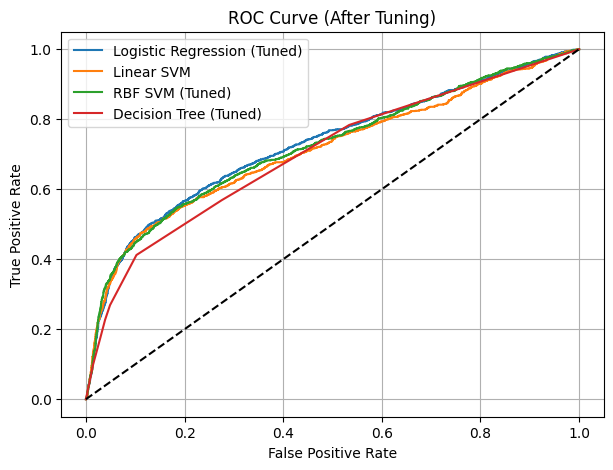

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Probabilities / decision scores
y_prob_log_tuned = best_log.predict_proba(X_test_scaled)[:, 1]

# Linear SVM (uses decision_function)
y_prob_svm_linear_tuned = svm_linear.decision_function(X_test_scaled)

# RBF SVM
y_prob_svm_rbf_tuned = best_svm_rbf.decision_function(X_test_scaled)

# Decision Tree
y_prob_tree_tuned = best_tree.predict_proba(X_test)[:, 1]

# ROC-AUC scores
print("ROC-AUC AFTER TUNING:")
print("Logistic Regression:", roc_auc_score(y_test, y_prob_log_tuned))
print("Linear SVM:", roc_auc_score(y_test, y_prob_svm_linear_tuned))
print("RBF SVM:", roc_auc_score(y_test, y_prob_svm_rbf_tuned))
print("Decision Tree:", roc_auc_score(y_test, y_prob_tree_tuned))

# ROC curves
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log_tuned)
fpr_linear, tpr_linear, _ = roc_curve(y_test, y_prob_svm_linear_tuned)
fpr_rbf, tpr_rbf, _ = roc_curve(y_test, y_prob_svm_rbf_tuned)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree_tuned)

# Plot
plt.figure(figsize=(7,5))

plt.plot(fpr_log, tpr_log, label="Logistic Regression (Tuned)")
plt.plot(fpr_linear, tpr_linear, label="Linear SVM")
plt.plot(fpr_rbf, tpr_rbf, label="RBF SVM (Tuned)")
plt.plot(fpr_tree, tpr_tree, label="Decision Tree (Tuned)")

plt.plot([0,1], [0,1], 'k--')  # baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (After Tuning)")
plt.legend()
plt.grid()

plt.show()

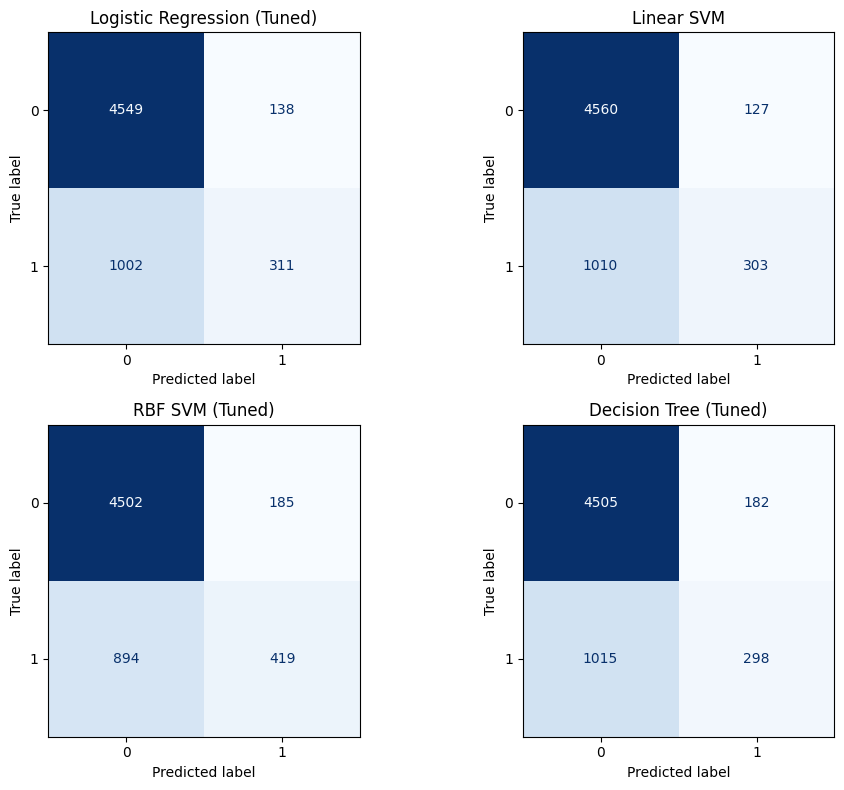

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions (tuned models)
y_pred_log_tuned = best_log.predict(X_test_scaled)
y_pred_svm_linear = svm_linear.predict(X_test_scaled)
y_pred_rbf_tuned = best_svm_rbf.predict(X_test_scaled)
y_pred_tree_tuned = best_tree.predict(X_test)

# Confusion matrices
cm_log = confusion_matrix(y_test, y_pred_log_tuned)
cm_linear = confusion_matrix(y_test, y_pred_svm_linear)
cm_rbf = confusion_matrix(y_test, y_pred_rbf_tuned)
cm_tree = confusion_matrix(y_test, y_pred_tree_tuned)

# Plot all together
fig, axes = plt.subplots(2, 2, figsize=(10,8))

# Logistic Regression
ConfusionMatrixDisplay(cm_log).plot(ax=axes[0,0], cmap='Blues', colorbar=False)
axes[0,0].set_title("Logistic Regression (Tuned)")

# Linear SVM
ConfusionMatrixDisplay(cm_linear).plot(ax=axes[0,1], cmap='Blues', colorbar=False)
axes[0,1].set_title("Linear SVM")

# RBF SVM
ConfusionMatrixDisplay(cm_rbf).plot(ax=axes[1,0], cmap='Blues', colorbar=False)
axes[1,0].set_title("RBF SVM (Tuned)")

# Decision Tree
ConfusionMatrixDisplay(cm_tree).plot(ax=axes[1,1], cmap='Blues', colorbar=False)
axes[1,1].set_title("Decision Tree (Tuned)")

plt.tight_layout()
plt.show()

RBF SVM performs the best in identifying defaulters due to highest true positives and lowest false negatives, while Logistic Regression provides the most balanced overall performance. Linear SVM is biased toward the majority class and tends to under-detect defaulters. and Decision Tree shows the weakest performance.

**Q1.4 Importance of data transformations**

Logistic regression without scaling

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_no_scale = LogisticRegression(max_iter=1000)

log_no_scale.fit(X_train, y_train)

y_pred_log_no_scale = log_no_scale.predict(X_test)

print("Logistic Regression Accuracy (No Scaling):",
      accuracy_score(y_test, y_pred_log_no_scale))

Logistic Regression Accuracy (No Scaling): 0.7973333333333333


Logistic regression with scaling

In [ ]:
log_scaled = LogisticRegression(max_iter=1000)

log_scaled.fit(X_train_scaled, y_train)

y_pred_log_scaled = log_scaled.predict(X_test_scaled)

print("Logistic Regression Accuracy (With Scaling):",
      accuracy_score(y_test, y_pred_log_scaled))

Logistic Regression Accuracy (With Scaling): 0.81


Decision Tree without scaling

In [ ]:
tree_no_scale = DecisionTreeClassifier(random_state=42)

tree_no_scale.fit(X_train, y_train)

y_pred_tree_no_scale = tree_no_scale.predict(X_test)

print("Decision Tree Accuracy (No Scaling):",
      accuracy_score(y_test, y_pred_tree_no_scale))

Decision Tree Accuracy (No Scaling): 0.7206666666666667


Decision tree with scaling

In [ ]:
tree_scaled = DecisionTreeClassifier(random_state=42)

tree_scaled.fit(X_train_scaled, y_train)

y_pred_tree_scaled = tree_scaled.predict(X_test_scaled)

print("Decision Tree Accuracy (With Scaling):",
      accuracy_score(y_test, y_pred_tree_scaled))

Decision Tree Accuracy (With Scaling): 0.725


Observation:
As we can observe that in case of logistic regression accuracy improved from 0.797 to 0.81 after scaling. This is because logistic regression is sensitive to feature scaling, it relies on gradient-based optimization. Without scaling, the model may experience convergence issues due to features with very different magnitudes. On the otehrt hand, decision trees model showed almost no change in performance (0.7207 vs 0.725), showing that it is not affected by feature scaling. This is because decision trees split data based on thresholds rather than distances. Therefore, scaling is essential for distance-based and linear models but not necessary for tree-based models.

**Q1.5 Stability of model comparison**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler   #
import pandas as pd

splits = [0.2, 0.3, 0.4]

results = []

for test_size in splits:

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # ADD SCALING HERE (AFTER SPLIT)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)   # fit on train
    X_test_scaled = scaler.transform(X_test)         # transform test

    # Logistic Regression (USE SCALED DATA)
    log = LogisticRegression(max_iter=1000)
    log.fit(X_train_scaled, y_train)
    log_acc = accuracy_score(y_test, log.predict(X_test_scaled))

    # Decision Tree (KEEP ORIGINAL DATA)
    tree = DecisionTreeClassifier(random_state=42)
    tree.fit(X_train, y_train)
    tree_acc = accuracy_score(y_test, tree.predict(X_test))

    results.append({
        "Test Size": test_size,
        "Logistic Regression": log_acc,
        "Decision Tree": tree_acc
    })

stability_results = pd.DataFrame(results)
stability_results

,Test Size,Logistic Regression,Decision Tree
0,0.2,0.810000,0.725500
1,0.3,0.808778,0.725778
2,0.4,0.808417,0.716750



As we can observe that logistic Regression maintains consistently high accuracy across different train-test splits,around 0.81. This indicates that the model is stable and less sensitive to variations in the training data. In contrast, Decision Tree model showed slightly more variation in performance, with accuracy ranging from 0.7167 to 0.7258. This suggests that Decision Trees are more sensitive to changes in the training dataset, they are high-variance models that rely heavily on the training data to determine split thresholds. When the training set becomes smaller, the decision tree structure can change significantly, thus leading to a reduced generalization performance.
Here, logistic Regression proves to be a more stable and reliable model in this comparison.

**Q1.6 Recursive feature elimination**

recreate the train/test split

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("default payment next month", axis=1)
y = df["default payment next month"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression

log = LogisticRegression(max_iter=1000)

rfecv = RFECV(
    estimator=log,
    step=1,
    cv=5,
    scoring="f1",
    min_features_to_select=5
)

rfecv.fit(X_train_scaled, y_train)

print("Optimal number of features:", rfecv.n_features_)

Optimal number of features: 5


In [ ]:
selected_features = X.columns[rfecv.support_]

print("\nSelected features:")
print(selected_features)



Selected features:
Index(['PAY_0', 'PAY_3', 'BILL_AMT1', 'PAY_AMT1', 'PAY_AMT2'], dtype='object')


Train the model only using those features

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X_train_opt = X_train_scaled[:, rfecv.support_]
X_test_opt = X_test_scaled[:, rfecv.support_]

# Train model
log_opt = LogisticRegression(max_iter=1000)
log_opt.fit(X_train_opt, y_train)

# Predict
y_pred_opt = log_opt.predict(X_test_opt)

# Evaluate
print("\nAccuracy with selected features:",
      accuracy_score(y_test, y_pred_opt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_opt))


Accuracy with selected features: 0.8081666666666667

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.70      0.22      0.33      1313

    accuracy                           0.81      6000
   macro avg       0.76      0.60      0.61      6000
weighted avg       0.79      0.81      0.77      6000



Observation:
For recursive feature elimination, the original feature set was used instead of PCA-transformed features, because PCA creates new transformed variables which are not directly interpretable.
Here, Recursive Feature Elimination (RFE) was applied to the Logistic regression model which was the best performing model. The optimal number of features selected was 5. These included key financial indicators, such as repayment status(PAY_0, PAY_3) and billing/payment amounts(BILL_AMT1, PAY_AMT1, PAY_AMT2). After training the model using only these selected features, the accuracy remained nearly the same (0.808) compared to the full feature set (0.81). This tells us that a smaller subset of important features can achieve similar predictive performance.
(which are strong indicators of credit default risk).
Hence, a smaller subset of informative features can also give you similar predictive performance as well as simplify the model.

**Q2 Bike sharing demand**

**Q.1 Explore the data**

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving hour.csv to hour (1).csv


In [ ]:
df = pd.read_csv("hour.csv")

df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


**label distribution**

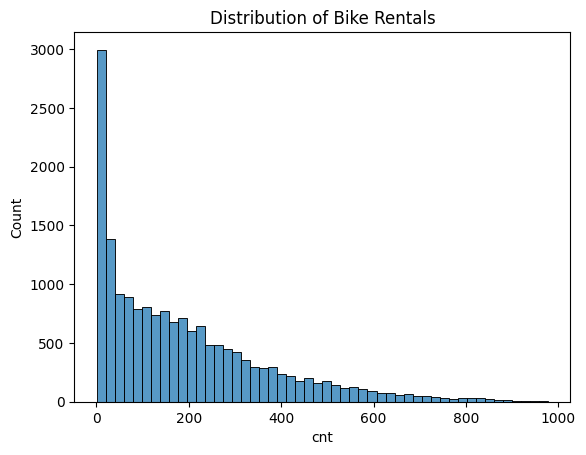

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["cnt"], bins=50)
plt.title("Distribution of Bike Rentals")
plt.show()

AFrom above graph we can observe the distribution of the target variable (cnt), which is the total number of bike rentals. The distribution is highly right-skewed, with most values concentrated at lower rental counts and a long tail of higher values. This tells us that low-demand periods are more frequent, while high-demand instances are relatively rare.

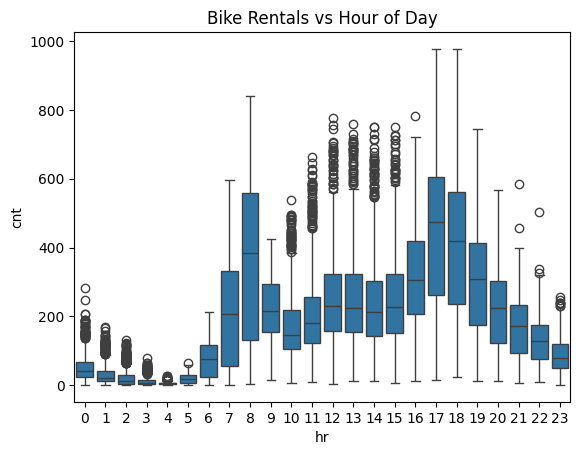

In [ ]:
sns.boxplot(x="hr", y="cnt", data=df)
plt.title("Bike Rentals vs Hour of Day")
plt.show()

The boxplot shows a clear relationship between the hour of the day and bike rental demand. Rentals are very low during early morning hours (midnight to 5 AM), then increase gradually in the morning, and peak during typical commuting hours (around 8-9 AM and 5-7 PM). As we can see that after evening hours, the demand decreases again. This pattern indicates strong temporal dependency, suggesting that hour of the day is an important predictor of bike rental demand.

/tmp/ipykernel_12458/539471808.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_group = df.groupby("temp_bin")["cnt"].mean().reset_index()


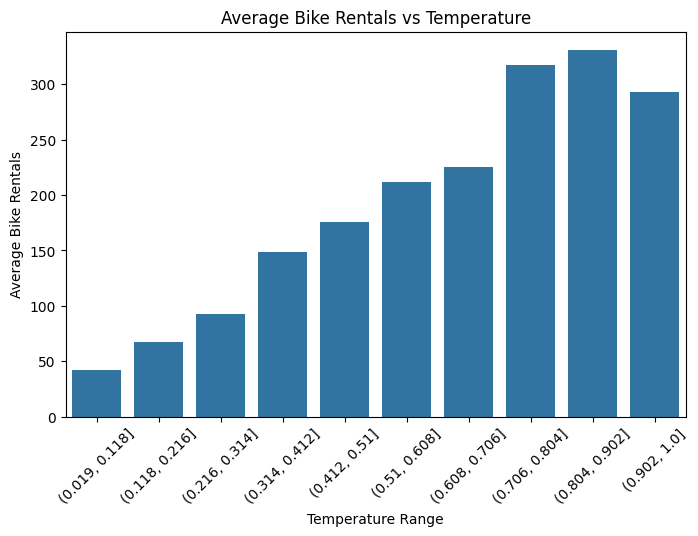

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create temperature bins
df["temp_bin"] = pd.cut(df["temp"], bins=10)

# Compute average rentals for each bin
temp_group = df.groupby("temp_bin")["cnt"].mean().reset_index()

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x="temp_bin", y="cnt", data=temp_group)

plt.xticks(rotation=45)
plt.title("Average Bike Rentals vs Temperature")
plt.xlabel("Temperature Range")
plt.ylabel("Average Bike Rentals")

plt.show()

Above plot is a bar plot which shows a clear increasing trend between temperature and bike rental demand. As temperature rises, the average number of bike rentals also increases, indicating that people are more likely to use bikes in warmer conditions. However, at the highest temperature range, there is a slight decline, this may suggest that extremely high temperatures may reduce bike usage. This indicates a strong positive relationship between temperature and bike rentals, with a possible nonlinear effect at extreme values.

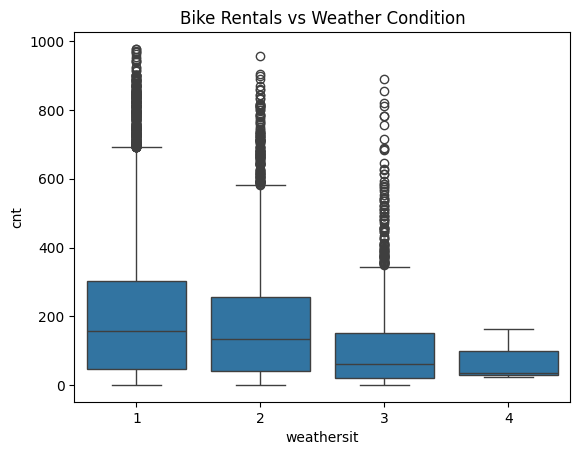

In [ ]:
sns.boxplot(x="weathersit", y="cnt", data=df)
plt.title("Bike Rentals vs Weather Condition")
plt.show()

The above boxplot shows that bike rental demand decreases as weather conditions worsen. Rentals are highest during clear weather (category 1), slightly lower in cloudy conditions (category 2), and significantly reduced during rainy or snowy conditions (category 3). The lowest rentals are observed during extreme weather conditions (category 4). This tells us that there is a strong negative relationship between adverse weather conditions and bike rental demand.

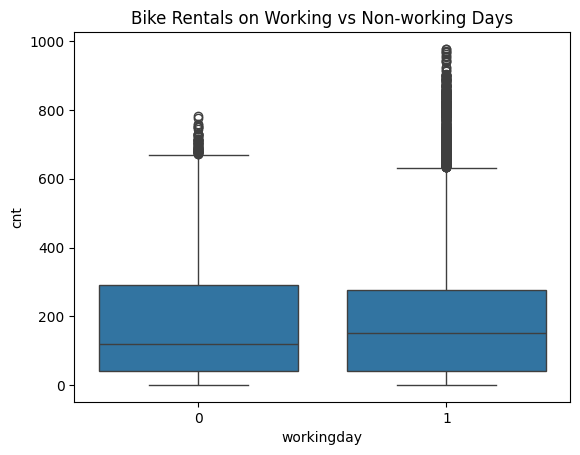

In [ ]:
sns.boxplot(x="workingday", y="cnt", data=df)
plt.title("Bike Rentals on Working vs Non-working Days")
plt.show()

The boxplot shows that bike rental demand is slightly higher on working days compared to non-working days. The median rental count is higher for working days, and there are more high-value observations, which tells us usage is increase. However, the difference is not very large, suggesting that while working days influence bike rentals, the effect is moderate compared to other factors such as hour or weather.

**Correlation heat map**

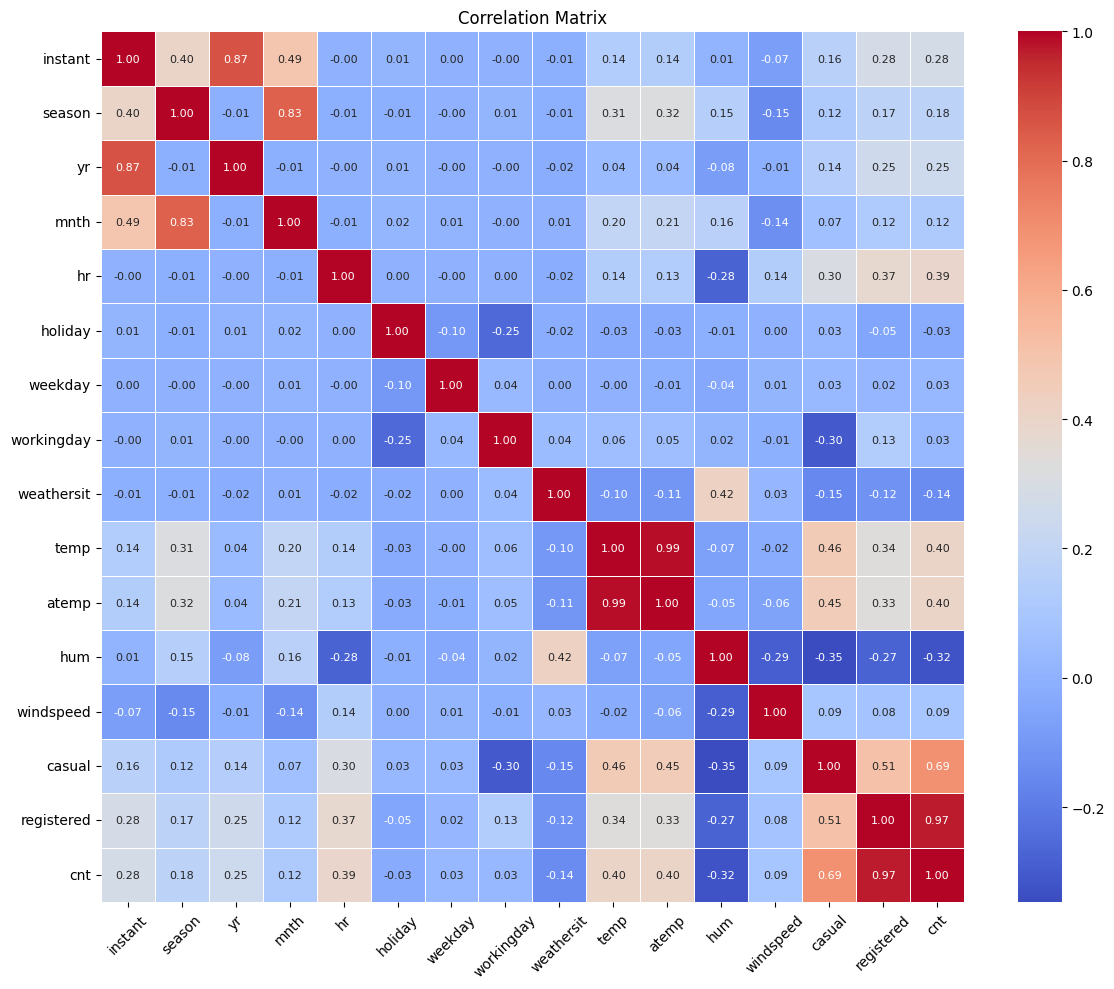

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))

corr = df.select_dtypes(include=['number']).corr()

sns.heatmap(
    corr,
    annot=True,          # show numbers
    fmt=".2f",           # 2 decimal places
    cmap="coolwarm",
    linewidths=0.5,      # grid lines
    annot_kws={"size": 8}  # smaller text if many variables
)

plt.title("Correlation Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Are there any strong associations between any input and output variable
that are immediately obvious?**

The correlation analysis shows that the variables casual and registered are highly correlated with the target variable cnt. This is because the total number of rentals (cnt) is the sum of these two variables. Including these features in the model would result in data leakage, as the model would have direct information about the target. Therefore, these variables must be removed before training machine learning models.
Among meaningful predictors, hour, temperature, and feels-like temperature show moderate positive correlations with bike rentals, while humidity exhibits a negative correlation. Additionally, temp and atemp are highly correlated with each other, indicating multicollinearity. Other variables such as holiday and weekday show weak correlations, suggesting limited linear influence on the target variable.

**What performance metrics should be used and why?**

Since the target variable cnt which is the total number of bike rentals and is a continuous variable, the problem is a regression task. Therefore, regression evaluation metrics should be used.
Metrics such as Mean Absolute Error (MAE),Root Mean Squared Error (RMSE) and R² are appropriate, as they measure the difference between predicted and actual rental counts. RMSE penalizes larger errors more heavily, making it useful when large prediction errors are undesirable, while MAE provides a more interpretable average error. R² Score (Coefficient of Determination) measures how well the model explains the variance in the target variable and gives information of overall model fit.These metrics are suitable because they capture prediction accuracy for continuous outcomes and are robust to the skewed distribution of the target variable.

**Q2.2 Data transformations**

In [ ]:
# Drop unnecessary / leakage features
df = df.drop(["instant", "dteday", "casual", "registered"], axis=1)

In [ ]:
#one-hot encoding
df = pd.get_dummies(df, columns=["season", "mnth", "hr", "weekday", "weathersit"], drop_first=True)

In [ ]:
df = df.drop("temp_bin", axis=1, errors='ignore')

In [ ]:
#feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# remove redundant feature
df = df.drop("atemp", axis=1, errors="ignore")

# scale numerical features
num_cols = ["temp", "hum", "windspeed"]
df[num_cols] = scaler.fit_transform(df[num_cols])

# split
X = df.drop("cnt", axis=1)
y = df["cnt"]

The dataset was preprocessed by removing irrelevant and redundant features. The variables casual and registered were removed to avoid data leakage, as they directly contribute to the target variable cnt. Additionally, instant and dteday were dropped since they do not provide useful predictive information. Due to high correlation between temp and atemp, they were also removed to reduce redundancy.

Categorical variables such as season, mnth, hr, weekday, and weathersit were transformed using one-hot encoding to avoid introducing artificial ordinal relationships. Numerical features including temp, hum, and windspeed were standardized using feature scaling to ensure uniform contribution across features.

The final dataset consists of fully numeric features suitable for regression modeling.

In [ ]:
# ===== FINAL VERIFICATION CHECK =====

print("1. Columns in dataset:\n")
print(X.columns)

print("\n-----------------------------")

print("2. Checking dropped columns (should be False):")
dropped_cols = ["casual", "registered", "instant", "dteday", "atemp"]
for col in dropped_cols:
    print(f"{col} present? ->", col in X.columns)

print("\n-----------------------------")

print("3. Data types (should be only int/float):")
print(X.dtypes.value_counts())

print("\n-----------------------------")

print("4. Check scaling (mean ~0, std ~1):")
print("\nMean:\n", X[["temp", "hum", "windspeed"]].mean())
print("\nStd:\n", X[["temp", "hum", "windspeed"]].std())

print("\n-----------------------------")

print("5. Check encoding (should show encoded columns):")
print([col for col in X.columns if "season" in col][:5])
print([col for col in X.columns if "hr" in col][:5])

print("\n-----------------------------")

print("6. Sample data:")
print(X.head())

1. Columns in dataset:

Index(['yr', 'holiday', 'workingday', 'temp', 'hum', 'windspeed', 'season_2',
       'season_3', 'season_4', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5',
       'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12',
       'hr_1', 'hr_2', 'hr_3', 'hr_4', 'hr_5', 'hr_6', 'hr_7', 'hr_8', 'hr_9',
       'hr_10', 'hr_11', 'hr_12', 'hr_13', 'hr_14', 'hr_15', 'hr_16', 'hr_17',
       'hr_18', 'hr_19', 'hr_20', 'hr_21', 'hr_22', 'hr_23', 'weekday_1',
       'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6',
       'weathersit_2', 'weathersit_3', 'weathersit_4'],
      dtype='object')

-----------------------------
2. Checking dropped columns (should be False):
casual present? -> False
registered present? -> False
instant present? -> False
dteday present? -> False
atemp present? -> False

-----------------------------
3. Data types (should be only int/float):
bool       46
int64       3
float64     3
Name: count, dtype: int64

----------------

**Q2.3 ML model type**

In [ ]:
# remove non-numeric engineered column
X = X.drop("temp_bin", axis=1, errors='ignore')

In [ ]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(13903, 52) (3476, 52)


In [ ]:
#Import model
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
#Linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
#SVR linear
from sklearn.svm import SVR

svr_linear = SVR(kernel='linear')
svr_linear.fit(X_train, y_train)

y_pred_svr_linear = svr_linear.predict(X_test)

In [ ]:
#SVR RBF
svr_rbf = SVR(kernel='rbf')
svr_rbf.fit(X_train, y_train)

y_pred_svr_rbf = svr_rbf.predict(X_test)

In [ ]:
#Decision tree
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

def evaluate(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"{name} → MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.3f}")



In [ ]:
evaluate("Linear Regression", y_test, y_pred_lr)
evaluate("SVR Linear", y_test, y_pred_svr_linear)
evaluate("SVR RBF", y_test, y_pred_svr_rbf)
evaluate("Decision Tree", y_test, y_pred_dt)

Linear Regression → MAE: 74.10, RMSE: 100.50, R²: 0.681
SVR Linear → MAE: 74.39, RMSE: 109.80, R²: 0.619
SVR RBF → MAE: 91.85, RMSE: 138.70, R²: 0.392
Decision Tree → MAE: 43.89, RMSE: 74.44, R²: 0.825


Among the evaluated models, the Decision Tree achieved the best performance with the lowest MAE (43.89), lowest RMSE (74.44), and highest R² (0.825).This suggests that the relationship between input features and bike demand is non-linear, which tree-based models can effectively capture.

Linear Regression showed moderate performance (MAE = 74.10,RMSE= 100.50, R² = 0.681), while SVR models performed worse, especially SVR RBF with the highest MAE (91.85) and lowest R² (0.392). This suggests that default SVR parameters were not suitable for the dataset. Overall, the Decision Tree model was the most suitable for this dataset.

Hyperparameter tuning was performed on models that are sensitive to parameter selection, namely Decision Tree and SVR with RBF kernel. Linear Regression was not tuned as it does not involve significant hyperparameters.

In [ ]:
#linear regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    "fit_intercept": [True, False]
}

lr = LinearRegression()

grid_lr = GridSearchCV(
    lr,
    param_grid_lr,
    cv=3,
    scoring="neg_mean_squared_error"
)

grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_

y_pred_lr_tuned = best_lr.predict(X_test)

evaluate("Linear Regression Tuned", y_test, y_pred_lr_tuned)
print(grid_lr.best_params_)

Linear Regression Tuned → MAE: 74.10, RMSE: 100.50, R²: 0.681
{'fit_intercept': True}


Hyperparameter tuning for Linear Regression was performed using the fit_intercept parameter. However, no improvement in performance was observed, as the default configuration already provided optimal results. This suggests that Linear Regression has limited flexibility and does not improve significantly from hyperparameter tuning.

In [ ]:
#Simple SVM
from sklearn.svm import SVR

param_grid_svr_linear = {
    "C": [0.1, 1, 10],
    "epsilon": [0.1, 0.2]
}

svr_linear = SVR(kernel='linear')

grid_svr_linear = GridSearchCV(
    svr_linear,
    param_grid_svr_linear,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_svr_linear.fit(X_train, y_train)

best_svr_linear = grid_svr_linear.best_estimator_

y_pred_svr_linear_tuned = best_svr_linear.predict(X_test)

evaluate("SVR Linear Tuned", y_test, y_pred_svr_linear_tuned)
print(grid_svr_linear.best_params_)

SVR Linear Tuned → MAE: 70.88, RMSE: 104.57, R²: 0.655
{'C': 10, 'epsilon': 0.2}


Hyperparameter tuning of SVR with a linear kernel resulted in slight improvement, with MAE and RMSE decreasing and R² increasing marginally. However, the performance remained low compared to non-linear models such as Decision Tree and SVR with RBF kernel. This is because linear models are unable to capture complex, non-linear relationships in the dataset.

In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

param_grid_svr = {
    "C": [1, 10],
    "gamma": ["scale", 0.01],
    "epsilon": [0.1, 0.2]
}

svr = SVR(kernel='rbf')

grid_svr = GridSearchCV(
    svr,
    param_grid_svr,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_svr.fit(X_train, y_train)

# best model
best_svr = grid_svr.best_estimator_

# prediction
y_pred_svr_tuned = best_svr.predict(X_test)

In [ ]:
evaluate("SVR RBF Tuned", y_test, y_pred_svr_tuned)
print(grid_svr.best_params_)

SVR RBF Tuned → MAE: 58.35, RMSE: 93.56, R²: 0.724
{'C': 10, 'epsilon': 0.1, 'gamma': 'scale'}


Hyperparameter tuning significantly improved the performance of the SVR model with RBF kernel. The MAE decreased from 91.85 to 58.35 and RMSE decreased from 138.70 to 93.56, and R² increased from 0.392 to 0.724.

In [ ]:
#Decision tree
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

param_grid_dt = {
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

dt = DecisionTreeRegressor(random_state=42)

grid_dt = GridSearchCV(
    dt,
    param_grid_dt,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

# Best model
best_dt = grid_dt.best_estimator_

# Prediction
y_pred_dt_tuned = best_dt.predict(X_test)

In [ ]:
evaluate("Decision Tree Tuned", y_test, y_pred_dt_tuned)
print(grid_dt.best_params_)

Decision Tree Tuned → MAE: 39.88, RMSE: 66.29, R²: 0.861
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}


Hyperparameter tuning was performed for the Decision Tree model using GridSearchCV. The tuned model showed improved performance, with RMSE decreasing from 74.44 to 66.29 and R² increasing from 0.825 to 0.861. This indicates better generalization and reduced prediction error compared to the baseline model.

In [ ]:
import pandas as pd

results_compare = pd.DataFrame({

    "Model": ["Linear Regression", "SVR Linear", "SVR RBF", "Decision Tree"],

    # BEFORE tuning (from your output)
    "MAE (Before)": [74.10, 74.39, 91.85, 43.89],
    "RMSE (Before)": [100.50, 109.80, 138.70, 74.44],
    "R2 (Before)": [0.681, 0.619, 0.392, 0.825],

    # AFTER tuning (from your output)
    "MAE (After)": [74.10, 70.88, 58.35, 39.88],
    "RMSE (After)": [100.50, 104.57, 93.56, 66.29],
    "R2 (After)": [0.681, 0.655, 0.724, 0.861],

})

results_compare

,Model,MAE (Before),RMSE (Before),R2 (Before),MAE (After),RMSE (After),R2 (After)
0,Linear Regression,74.10,100.50,0.681,74.10,100.50,0.681
1,SVR Linear,74.39,109.80,0.619,70.88,104.57,0.655
2,SVR RBF,91.85,138.70,0.392,58.35,93.56,0.724
3,Decision Tree,43.89,74.44,0.825,39.88,66.29,0.861


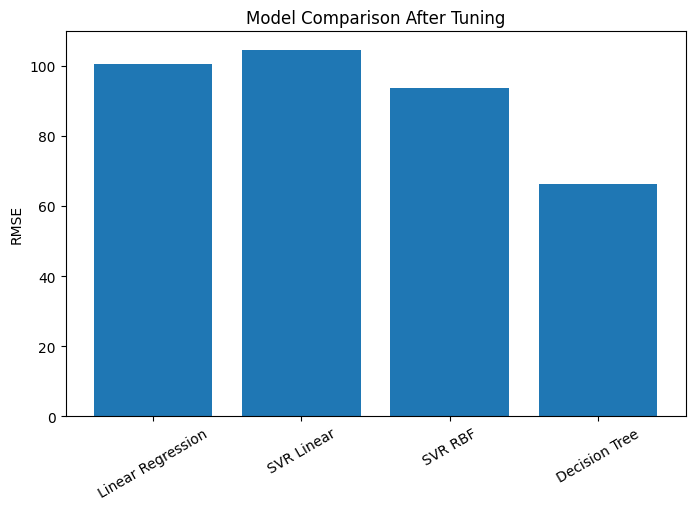

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_compare["Model"], results_compare["RMSE (After)"])
plt.title("Model Comparison After Tuning")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.show()

**Depending on the inputs and EDA, which of these were likely to work better depending on input variables and their association with the output variable? Did the observations meet your expectations?**


Based on the EDA, features such as hour, temperature, and weather showed non-linear relationships with bike rental demand. Therefore, non-linear models like Decision Trees and SVR with RBF kernel were expected to perform better.

We saw that among all models, the tuned Decision Tree performed the best, achieving the lowest MAE, RMSE, and highest R² score. This indicates that the dataset contains strong non-linear relationships that are effectively captured by tree-based models.

The SVR model with RBF kernel showed significant improvement after tuning, demonstrating its ability to model non-linear patterns. Linear models such as Linear Regression and SVR with a linear kernel showed comparatively lower performance due to their inability to capture complex relationships in the data.

Overall, the results align with the earlier observations from EDA. The observations met the expectations.

**Q 2.4 Appropriateness of splits**

In [ ]:
# reload clean data
df_time = pd.read_csv("hour.csv")

# sort by date
df_time = df_time.sort_values(by="dteday").reset_index(drop=True)

# split
split_index = int(0.8 * len(df_time))

train_df = df_time.iloc[:split_index]
test_df = df_time.iloc[split_index:]

In [ ]:
#Separate X and y
y_train = train_df["cnt"]
X_train = train_df.drop("cnt", axis=1)

y_test = test_df["cnt"]
X_test = test_df.drop("cnt", axis=1)

In [ ]:
#Drop leakage + unnecessary columns
cols_to_drop = ["casual", "registered", "instant", "dteday"]

X_train = X_train.drop(cols_to_drop, axis=1)
X_test = X_test.drop(cols_to_drop, axis=1)

In [ ]:
#Drop redundant feature
X_train = X_train.drop("atemp", axis=1)
X_test = X_test.drop("atemp", axis=1)

In [ ]:
#one hot encoding
X_train = pd.get_dummies(X_train, columns=["season", "mnth", "hr", "weekday", "weathersit"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["season", "mnth", "hr", "weekday", "weathersit"], drop_first=True)

In [ ]:
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

In [ ]:
#scaling fit only on train
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ["temp", "hum", "windspeed"]

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

Train model

In [ ]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=None, min_samples_split=10, min_samples_leaf=1, random_state=42)

model.fit(X_train, y_train)

DecisionTreeRegressor(min_samples_split=10, random_state=42)

In [ ]:
y_pred_time = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_time)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_time))
r2 = r2_score(y_test, y_pred_time)

print(f"Temporal Split → MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.3f}")

Temporal Split → MAE: 67.17, RMSE: 103.02, R2: 0.781


Decision Tree was chosen for temporal evaluation because it showed the best performance during initial model comparison, having the highest R² and lowest RMSE and MAE. This is due to its ability to capture nonlinear relationships between features such as temperature, time, and demand. However, when evaluated using temporal splits(training on past data and testing on future data), the model performance decreases compared to random splits. In our case, the R² dropped from ~0.861 to ~0.781 and RMSE increased from ~66 to ~103 and MAE increased to 67.17.
So, the performance decreased compared to random splitshis happens because random splits mix past and future data, allowing the model to learn patterns that may not be available in real-world future predictions, causing overly optimistic performance. In contrast, temporal splits ensure that the model is evaluated on truly unseen future data, making it a more realistic and reliable measure of performance. Other models like Linear Regression and SVR were not selected as they showed lower performance and are less capable of capturing complex nonlinear relationships in the data.

**Q2.5 Feature importance**

**Method 1: Permutation Importance**

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

# convert to dataframe
import pandas as pd

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean
})

# sort
importance_df = importance_df.sort_values(by="importance", ascending=False)

print(importance_df.head(10))

       feature  importance
36       hr_17    0.284789
2   workingday    0.283187
27        hr_8    0.280104
3         temp    0.276771
37       hr_18    0.249298
4          hum    0.150370
38       hr_19    0.119180
26        hr_7    0.072649
35       hr_16    0.066397
28        hr_9    0.051923


Using permutation importance, features related to the hour of the day (such as hr_8, hr_17, hr_18) were found to be the most important, indicating strong temporal patterns in bike usage, mostly during commuting hours. The workingday feature was also highly important, showing differences between weekdays and weekends. Among environmental factors, temperature showed significant importance, followed by humidity. This suggests that both temporal and weather-related variables strongly influence bike rental demand.

**Method 2: Drop-column importance**

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# baseline
baseline_model = DecisionTreeRegressor(max_depth=None, min_samples_split=10, min_samples_leaf=1, random_state=42)
baseline_model.fit(X_train, y_train)

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_model.predict(X_test)))

drop_importance = {}

for col in X_train.columns:

    # drop feature from both train and test
    X_train_drop = X_train.drop(col, axis=1)
    X_test_drop = X_test.drop(col, axis=1)

    # retrain model
    model_drop = DecisionTreeRegressor(max_depth=None, min_samples_split=10, min_samples_leaf=1, random_state=42)
    model_drop.fit(X_train_drop, y_train)

    # predict
    y_pred_drop = model_drop.predict(X_test_drop)

    # compute rmse
    rmse_drop = np.sqrt(mean_squared_error(y_test, y_pred_drop))

    drop_importance[col] = rmse_drop - baseline_rmse

# dataframe
drop_df = pd.DataFrame({
    "feature": drop_importance.keys(),
    "importance": drop_importance.values()
})

drop_df = drop_df.sort_values(by="importance", ascending=False)

print(drop_df.head(10))

       feature  importance
27        hr_8   41.268376
36       hr_17   36.471165
3         temp   36.136466
2   workingday   31.980346
0           yr   27.340498
37       hr_18   26.246121
26        hr_7   15.274059
28        hr_9   14.946923
38       hr_19   12.765194
39       hr_20   11.917259


Feature importance was carried out using permutation importance and drop-column importance. Both methods identified time-related features (such as hr_8, hr_17, hr_18) as the most important, showing strong temporal patterns in bike usage during peak commuting hours. Temperature was also a key factor, showing that environmental conditions significantly influence demand. The workingday feature was important, showing differences between weekdays and weekends. Additionally, the year feature (yr) showed importance, indicating a temporal growth trend in bike usage over time. There is similarity seen in feature rankings across both methods which strengthens the reliability of these findings. Although the magnitude of importance values differed due to different evaluation metrics (R² for permutation importance and RMSE for drop-column importance), the relative importance of features remained consistent.


**Q3 Wine Quality**

**For red wine**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving winequality-red.csv to winequality-red (1).csv


**Q3.1 Explore the data**

In [ ]:
import pandas as pd

df_red = pd.read_csv("winequality-red.csv", sep=';')

print(df_red.shape)
df_red.head()

(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
# data types
print(df_red.dtypes)

# missing values
print(df_red.isnull().sum())

# summary
df_red.describe()

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


The task is to predict wine quality based on physicochemical properties. The target variable quality is an integer score (ranging from 3 to 8 in this dataset), making it a regression problem, although it can also be treated as a classification or ordinal regression problem.

**Distribution**

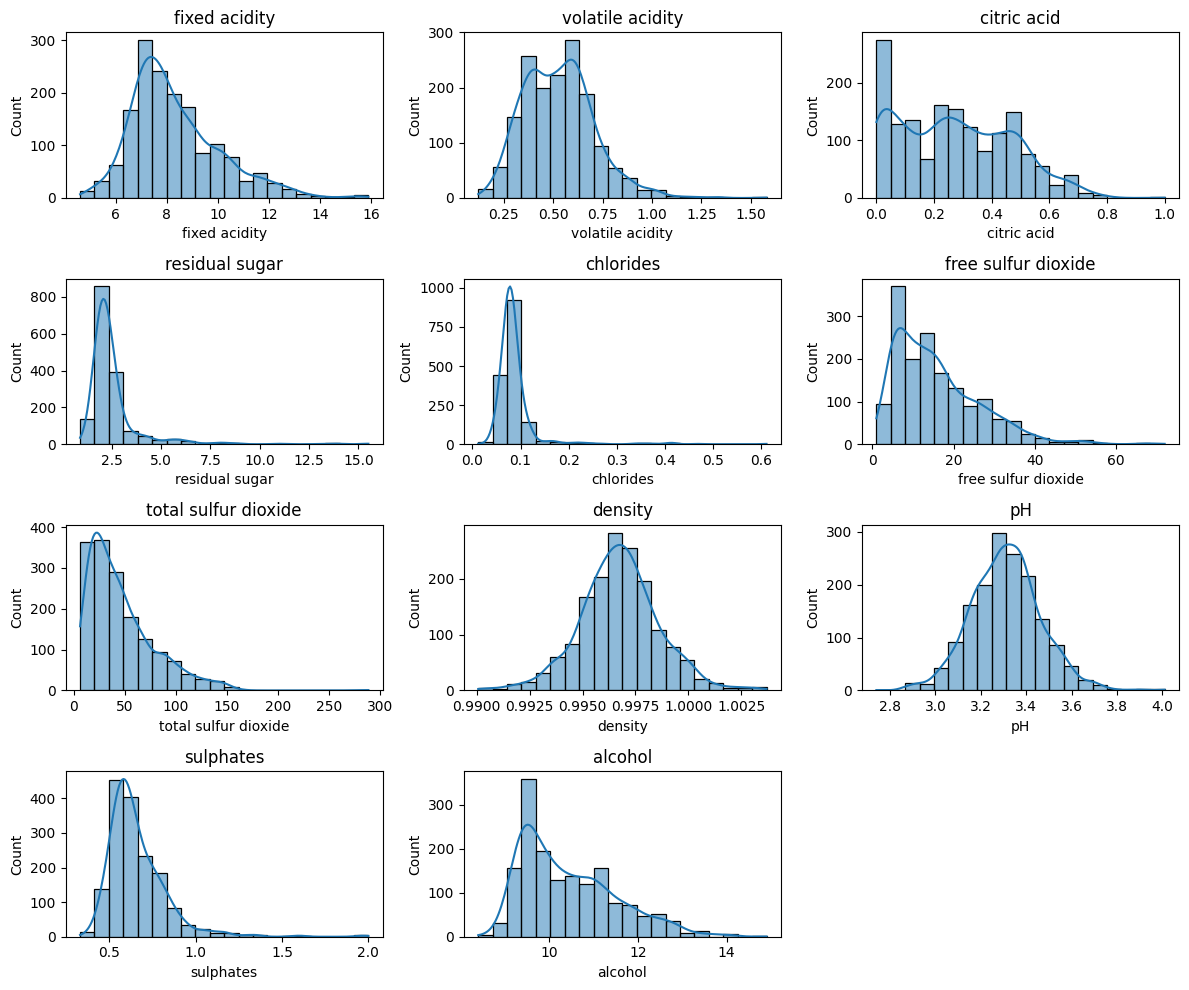

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df_red.columns[:-1]  # exclude 'quality'

plt.figure(figsize=(12,10))

for i, col in enumerate(num_cols):
    plt.subplot(4, 3, i+1)
    sns.histplot(df_red[col], bins=20, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

**Correlation Heatmap**

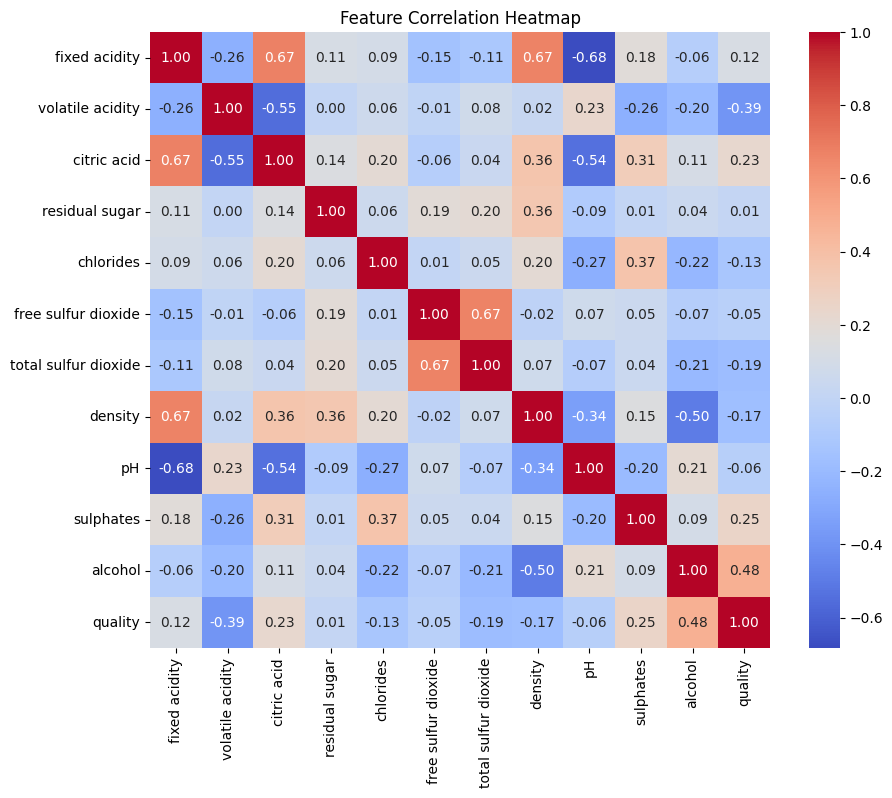

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df_red.corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

**Are there any strong associations between any input and output variable
that are immediately obvious?**

The correlation heatmap shows that alcohol has the strongest positive correlation with wine quality, sthis sauggest that wines with higher alcohol content tend to receive higher quality ratings.
Volatile acidity is negatively correlated with quality, suggesting that increased acidity reduces wine quality.
Sulphates show a moderate positive correlation, contributing positively to wine quality.
on the other hand, free sulfur dioxide and total sulfur dioxide are strongly positively correlated, indicating redundancy.Density is negatively correlated with alcohol and positively with residual sugar, showing interdependence among physicochemical properties.
Most other features show weak correlations, suggesting that they will have limited direct influence on quality.

Overall, the dataset shows moderate feature interactions with some multicollinearity, but no single feature completely determines the target.

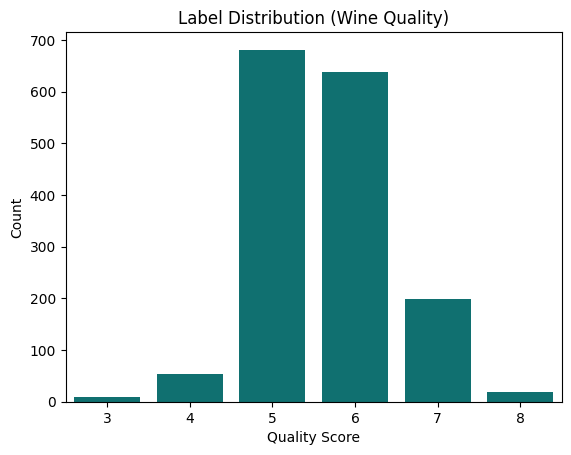

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df_red["quality"], color='teal')
plt.title("Label Distribution (Wine Quality)")
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.show()

The distribution of the target variable (wine quality) shows that it is discrete and takes integer values ranging from 3 to 8. Most samples are concentrated around quality scores of 5 and 6, an imbalanced distribution. Very few samples belong to extreme classes such as 3, 4, or 8.
This imbalance suggests that treating the problem as a pure classification task may lead to biased predictions toward dominant classes.

**What performance metrics should be used and why?**

Here, regression can be used because the target variable is numerical and ordered. Even though it is discrete, the values have meaningful differences, allowing regression models to learn and predict continuous approximations of wine quality. regression metrics such as MAE, RMSE, and R² should be used.MAE measures average error, RMSE penalizes large errors, and R² evaluates how well the model explains variance.

**For white wine**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving winequality-white.csv to winequality-white.csv


In [ ]:
df_white = pd.read_csv("winequality-white.csv", sep=";")

print(df_white.shape)
df_white.head()

(4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [ ]:
print(df_white.dtypes)
print(df_white.isnull().sum())
df_white.describe()

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


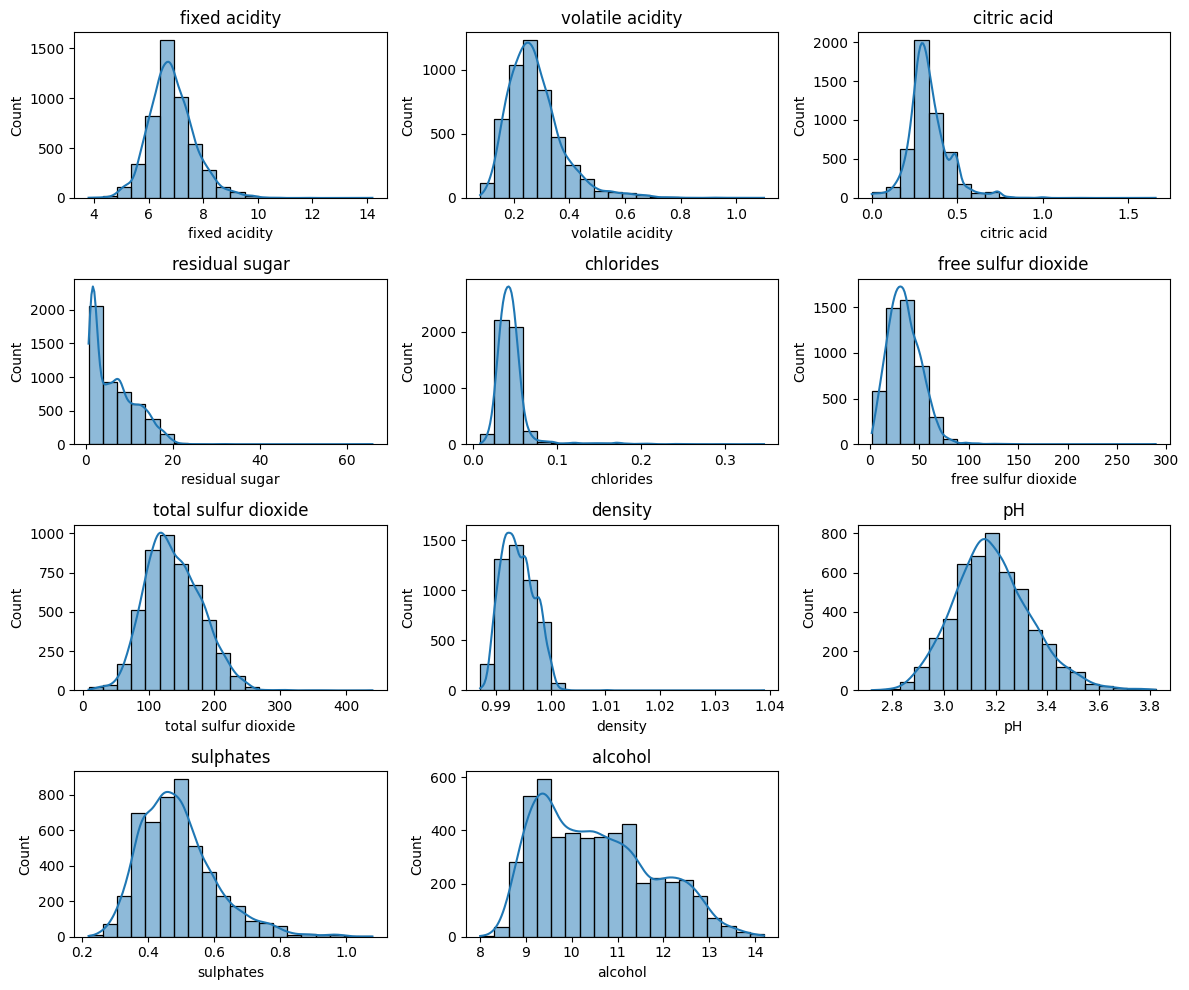

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# exclude target column
num_cols = df_white.columns[:-1]   # removes 'quality'

plt.figure(figsize=(12, 10))

for i, col in enumerate(num_cols):
    plt.subplot(4, 3, i + 1)
    sns.histplot(df_white[col], bins=20, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

**Correlation heatmap**

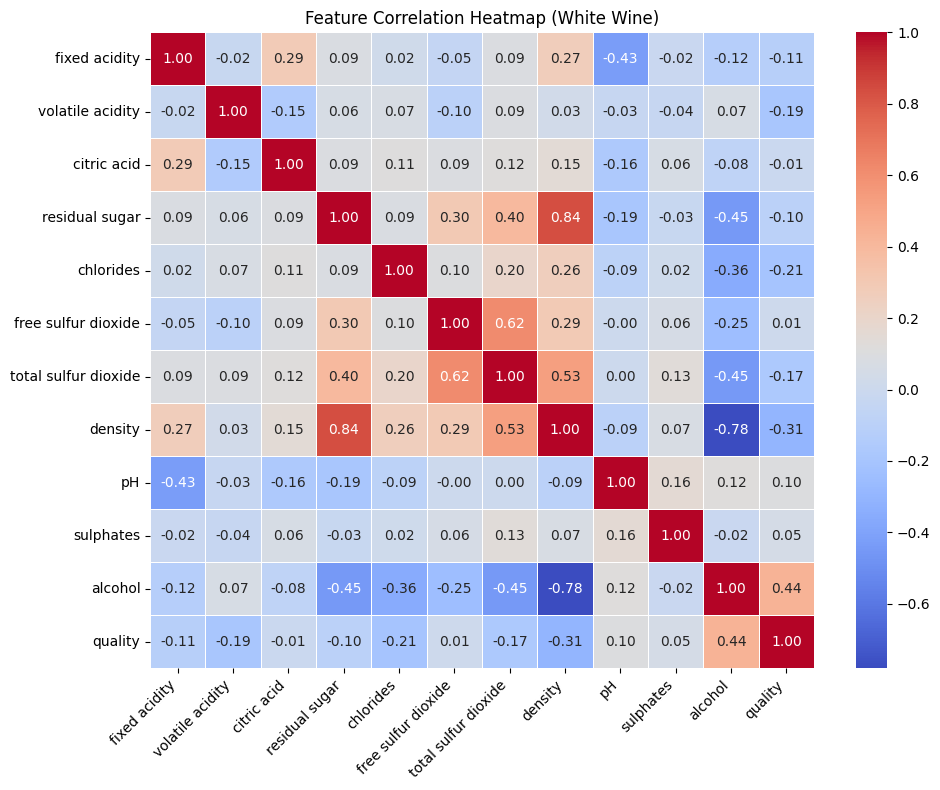

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    df_white.corr(),
    cmap="coolwarm",
    annot=True,        # shows values inside boxes
    fmt=".2f",         # 2 decimal places
    linewidths=0.5     # adds grid lines (clean look)
)

plt.title("Feature Correlation Heatmap (White Wine)")
plt.xticks(rotation=45, ha='right')   # rotate x labels
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Are there any strong associations between any input and output variable
that are immediately obvious?**

The correlation heatmap shows that alcohol has the strongest positive correlation with wine quality, indicating that higher alcohol content is associated with better quality. Density and residual sugar are strongly correlated with each other, suggesting redundancy between these features. Volatile acidity shows a slight negative relationship with quality. Overall, most features have weak to moderate correlations with the target variable, indicating that wine quality depends on multiple factors rather than a single dominant feature.

Compared to red wine, the correlations in white wine are generally weaker, suggesting that predicting quality in white wine may be more challenging

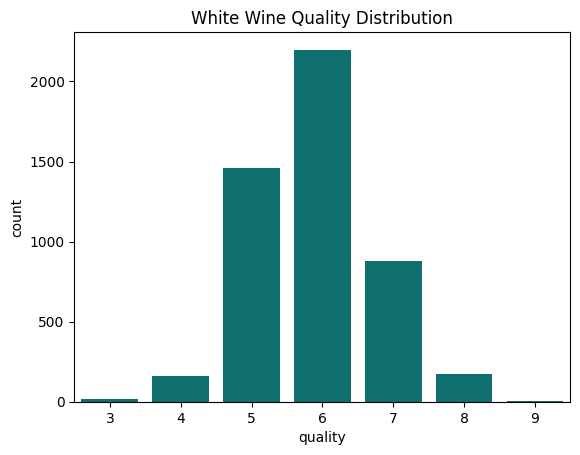

In [ ]:
sns.countplot(x=df_white["quality"], color='teal')
plt.title("White Wine Quality Distribution")
plt.show()

The distribution of wine quality shows that most samples are concentrated around quality scores of 5 and 6, with 6 being the most frequent. Very few samples exist at the extremes (quality 3, 8, and 9), showing an imbalanced distribution. This suggests that the dataset is skewed toward average-quality wines.

The imbalance in quality labels may affect model performance, as the model will be biased toward predicting the majority classes (5 and 6).

Since the target variable is ordinal and imbalanced, regression-based approaches may be more suitable than classification.

**What performance metrics should be used and why?**

Since the target variable (quality) is numerical and ordered, the problem is best treated as a regression task. Suitable evaluation metrics include RMSE, MAE, and R² score, as they effectively measure prediction error and model performance for continuous outputs.

**3.2 Data transformations**

Red wine

In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# Step 1: Copy data
df_red_log = df_red.copy()

# Step 2: Identify skewed columns
skewness_red = df_red.skew()
skewed_cols_red = skewness_red[skewness_red > 1].index

print("Red wine skewed columns:", list(skewed_cols_red))

# Step 3: Apply log transformation
for col in skewed_cols_red:
    df_red_log[col] = np.log1p(df_red_log[col])

# Step 4: Check skewness
print("\nRed Wine - Before transformation:\n", df_red.skew().round(2))
print("\nRed Wine - After LOG transformation:\n", df_red_log.skew().round(2))

# Step 5: Separate features & target
X_red = df_red_log.drop('quality', axis=1)
y_red = df_red_log['quality']

# Step 6: Scaling
scaler_red = StandardScaler()
X_red_scaled = scaler_red.fit_transform(X_red)

# Step 7: PCA
pca_red = PCA(n_components=0.95)
X_red_pca = pca_red.fit_transform(X_red_scaled)

print("\nRed wine shape after PCA:", X_red_pca.shape)




Red wine skewed columns: ['residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'sulphates']

Red Wine - Before transformation:
 fixed acidity           0.98
volatile acidity        0.67
citric acid             0.32
residual sugar          4.54
chlorides               5.68
free sulfur dioxide     1.25
total sulfur dioxide    1.52
density                 0.07
pH                      0.19
sulphates               2.43
alcohol                 0.86
quality                 0.22
dtype: float64

Red Wine - After LOG transformation:
 fixed acidity           0.98
volatile acidity        0.67
citric acid             0.32
residual sugar          2.26
chlorides               5.07
free sulfur dioxide    -0.10
total sulfur dioxide   -0.04
density                 0.07
pH                      0.19
sulphates               1.61
alcohol                 0.86
quality                 0.22
dtype: float64

Red wine shape after PCA: (1599, 8)


Data transformation was performed to adress the skewness in the red wine dataset. Highly skewed features such as residual sugar, chlorides, sulphates, and sulfur dioxide were observed and log transformation was applied. This reduced skewness significantly and improved the distribution of most variables, although some features remained moderately skewed due to inherent data characteristics.

The features were then standardized using StandardScaler to ensure uniform scaling. Finally, PCA was applied for dimensionality reduction, reducing the number of features while retaining 95% of the variance. This helped remove redundancy among correlated variables and improved computational efficiency without significant loss of information.

White wine

In [ ]:


# Step 1: Copy data
df_white_log = df_white.copy()

# Step 2: Identify skewed columns
skewness_white = df_white.skew()
skewed_cols_white = skewness_white[skewness_white > 1].index

print("\nWhite wine skewed columns:", list(skewed_cols_white))

# Step 3: Apply log transformation
for col in skewed_cols_white:
    df_white_log[col] = np.log1p(df_white_log[col])

# Step 4: Check skewness
print("\nWhite Wine - Before transformation:\n", df_white.skew().round(2))
print("\nWhite Wine - After LOG transformation:\n", df_white_log.skew().round(2))

# Step 5: Separate features & target
X_white = df_white_log.drop('quality', axis=1)
y_white = df_white_log['quality']

# Step 6: Scaling
scaler_white = StandardScaler()
X_white_scaled = scaler_white.fit_transform(X_white)

# Step 7: PCA
pca_white = PCA(n_components=0.95)
X_white_pca = pca_white.fit_transform(X_white_scaled)

print("\nWhite wine shape after PCA:", X_white_pca.shape)


White wine skewed columns: ['volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide']

White Wine - Before transformation:
 fixed acidity           0.65
volatile acidity        1.58
citric acid             1.28
residual sugar          1.08
chlorides               5.02
free sulfur dioxide     1.41
total sulfur dioxide    0.39
density                 0.98
pH                      0.46
sulphates               0.98
alcohol                 0.49
quality                 0.16
dtype: float64

White Wine - After LOG transformation:
 fixed acidity           0.65
volatile acidity        1.14
citric acid             0.61
residual sugar          0.00
chlorides               4.63
free sulfur dioxide    -0.83
total sulfur dioxide    0.39
density                 0.98
pH                      0.46
sulphates               0.98
alcohol                 0.49
quality                 0.16
dtype: float64

White wine shape after PCA: (4898, 9)


For white wine, several features such as volatile acidity, citric acid, residual sugar, chlorides, and sulfur dioxide showed skewed distributions. Log transformation was applied to reduce skewness. Most features showed significant improvement, although some variables like chlorides remained moderately skewed due to inherent data characteristics.

The data was then standardized using StandardScaler, followed by PCA to reduce dimensionality while retaining 95% of the variance.

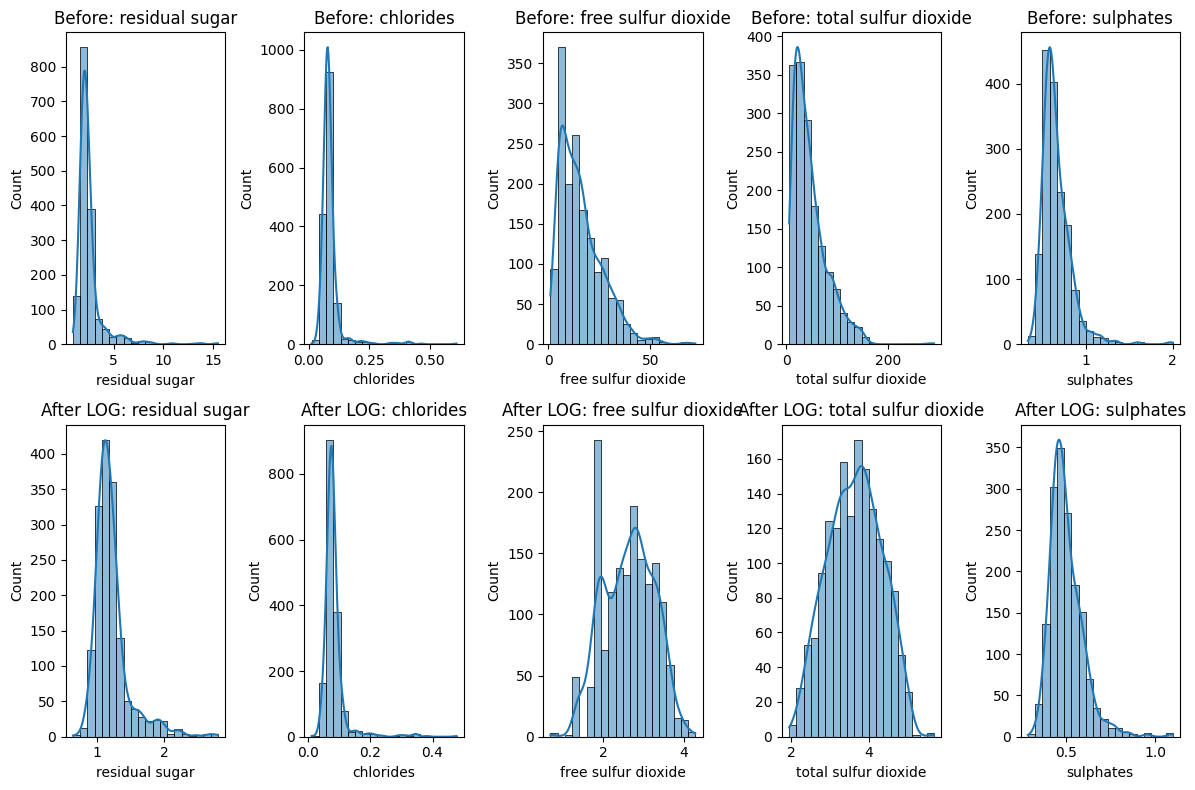

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'sulphates']

plt.figure(figsize=(12, 8))

for i, col in enumerate(cols):
    plt.subplot(2, len(cols), i+1)
    sns.histplot(df_red[col], bins=20, kde=True)
    plt.title(f"Before: {col}")

    plt.subplot(2, len(cols), i+1+len(cols))
    sns.histplot(df_red_log[col], bins=20, kde=True)
    plt.title(f"After LOG: {col}")

plt.tight_layout()
plt.show()


**Q3.3 Problem formulation**

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np

# split
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_red_pca, y_red, test_size=0.2, random_state=42
)

# model
reg_red = MLPRegressor(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
reg_red.fit(Xr_train, yr_train)

# prediction
y_pred = reg_red.predict(Xr_test)

# evaluation
print("RED WINE REGRESSION:")
print("MAE:", mean_absolute_error(yr_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(yr_test, y_pred)))
print("R2:", r2_score(yr_test, y_pred))

# WHITE WINE
Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_white_pca, y_white, test_size=0.2, random_state=42
)

reg_white = MLPRegressor(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
reg_white.fit(Xw_train, yw_train)

y_pred_white = reg_white.predict(Xw_test)

print("\nWHITE WINE REGRESSION:")
print("MAE:", mean_absolute_error(yw_test, y_pred_white))
print("RMSE:", np.sqrt(mean_squared_error(yw_test, y_pred_white)))
print("R2:", r2_score(yw_test, y_pred_white))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


RED WINE REGRESSION:
MAE: 0.5007241823243994
RMSE: 0.6319102296116696
R2: 0.3889717550967857

WHITE WINE REGRESSION:
MAE: 0.5456421302201397
RMSE: 0.7021788543134022
R2: 0.36336701635852353


The regression model achieved an RMSE of approximately 0.63 for red wine and 0.70 for white wine, with R² scores of around 0.39 and 0.36, respectively. This tells us a moderate ability to capture the relationship between features and wine quality. The relatively low RMSE suggests that predictions are reasonably close to actual values. However, the moderate R² values show that a significant portion of variance remains unexplained. Additionally, regression does not account for the discrete and ordered nature of wine quality, limiting its usecase vfor this problem.

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# TRAIN on TRAIN data
clf_red = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
clf_red.fit(Xr_train, yr_train)

# TEST prediction
y_pred_red_clf = clf_red.predict(Xr_test)

print("RED WINE CLASSIFICATION:")
print("Accuracy:", accuracy_score(yr_test, y_pred_red_clf))
print(classification_report(yr_test, y_pred_red_clf))

# WHITE WINE CLASSIFICATION
clf_white = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
clf_white.fit(Xw_train, yw_train)

y_pred_white_clf = clf_white.predict(Xw_test)

print("\nWHITE WINE CLASSIFICATION:")
print("Accuracy:", accuracy_score(yw_test, y_pred_white_clf))
print(classification_report(yw_test, y_pred_white_clf))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


RED WINE CLASSIFICATION:
Accuracy: 0.621875
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.50      0.10      0.17        10
           5       0.66      0.75      0.70       130
           6       0.62      0.61      0.61       132
           7       0.55      0.50      0.53        42
           8       0.00      0.00      0.00         5

    accuracy                           0.62       320
   macro avg       0.39      0.33      0.33       320
weighted avg       0.61      0.62      0.61       320


WHITE WINE CLASSIFICATION:
Accuracy: 0.5581632653061225
              precision    recall  f1-score   support

           3       0.50      0.20      0.29         5
           4       0.36      0.20      0.26        25
           5       0.58      0.62      0.60       291
           6       0.55      0.67      0.60       432
           7       0.55      0.37      0.44       192
           8       0.43      0.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


The classification model achieved an accuracy of approximately 62% for red wine and 56% for white wine, suggseting moderate performance. The model performs well for majority classes (5 and 6) but poorly for minority classes (3, 4, and 8), as seen from very low precision and recall. The lower macro F1-score compared to the weighted F1-score highlights the effect of class imbalance. Additionally, classification does not consider the ordered nature of wine quality, treating all errors equally. Therefore, while accuracy is reasonable, the model is biased toward common classes and is less suitable for this problem.

In [ ]:
import torch
import torch.nn as nn
import numpy as np

# ---------- STEP 1: Ordinal label creation ----------
def create_ordinal_labels(y, num_classes):
    y = y.astype(int)
    ordinal = []

    for k in range(num_classes - 1):
        ordinal.append((y > k).astype(int))

    return np.stack(ordinal, axis=1)


# ---------- STEP 2: Improved Model ----------
class OrdinalNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

        self.output = nn.Linear(hidden_dim // 2, num_classes - 1)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.relu(self.fc2(x))
        x = self.output(x)

        return x


# ---------- STEP 3: Training ----------
def train_model(X_train, y_train, num_classes, epochs=200):

    X_tensor = torch.tensor(X_train, dtype=torch.float32)

    y_ord = create_ordinal_labels(y_train, num_classes)
    y_tensor = torch.tensor(y_ord, dtype=torch.float32)

    #increased hidden size
    model = OrdinalNN(X_train.shape[1], 128, num_classes)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        model.train()

        outputs = model(X_tensor)
        loss = criterion(outputs, y_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return model


# ---------- STEP 4: Prediction ----------
def predict(model, X):
    model.eval()

    with torch.no_grad():
        X_tensor = torch.tensor(X, dtype=torch.float32)

        outputs = torch.sigmoid(model(X_tensor))

        preds = (outputs > 0.5).int()

        # convert ordinal back to class
        final_pred = preds.sum(dim=1).numpy()

    return final_pred

In [ ]:
num_classes_red = len(np.unique(y_red))
model_red = train_model(Xr_train, yr_train.values, num_classes_red)
y_pred_red_ord = predict(model_red, Xr_test)


print("ORDINAL REGRESSION (RED):")
print("Accuracy:", accuracy_score(yr_test, y_pred_red_ord))
print("MAE:", mean_absolute_error(yr_test, y_pred_red_ord))
print("RMSE:", np.sqrt(mean_squared_error(yr_test, y_pred_red_ord)))



num_classes_white = len(np.unique(y_white))
model_white = train_model(Xw_train, yw_train.values, num_classes_white)
y_pred_white_ord = predict(model_white, Xw_test)

print("\nORDINAL REGRESSION (WHITE):")
print("Accuracy:", accuracy_score(yw_test, y_pred_white_ord))
print("MAE:", mean_absolute_error(yw_test, y_pred_white_ord))
print("RMSE:", np.sqrt(mean_squared_error(yw_test, y_pred_white_ord)))


ORDINAL REGRESSION (RED):
Accuracy: 0.40625
MAE: 0.759375
RMSE: 1.059186008215743

ORDINAL REGRESSION (WHITE):
Accuracy: 0.5091836734693878
MAE: 0.5479591836734694
RMSE: 0.817537367304257


The three formulations regression, classification, and ordinal regression were used and they showed different behaviors for predicting red wine and white wine quality.
**Red Wine**
For the red wine dataset, the classification model achieved the highest accuracy (around 62%). The regression model showed moderate performance (RMSE ≈ 0.63, R² ≈ 0.39), showing that it can estimate values reasonably well but ignores the discrete and ordered nature of the labels. The ordinal regression model, although having lower accuracy (40%), produced a reasonable MAE (~0.76), meaning its predictions are generally close to the true values.

Practical Insight:
Ordinal regression provides more meaningful predictions as it captures the ordered nature of wine quality, While classification gives higher accuracy, it ignores the severity of prediction errors and rRegression provides good numerical estimates but does not capture the ordered nature of the target variable.

**White Wine**
For the white wine dataset, classification again showed higher accuracy (around 56%), but similar to red wine. The regression model achieved moderate performance (RMSE ≈ 0.70, R² ≈ 0.36), giving reasonable numerical predictions but ignoring the ordered structure of quality levels. The ordinal regression model performed better than in the red wine case, with accuracy around 48-51% and a lower MAE (~0.54), suggesting that predictions are closer to the true labels.
Practical Insight:
For white wine, ordinal regression again provides the most meaningful predictions because it effectively captures the ranking of wine quality.  Regression provides reasonable estimates but ignores ordering, while classification fails to capture the severity of errors. Thus, ordinal regression is the most suitable approach for practical applications where relative prediction accuracy is more important than exact class matching

**Q3.4 Distribution shift**

1. Hypothesis

A model trained on red wine data is not expected to perform well on white wine data, and vice versa. This is because the two datasets differ in feature distributions and their relationships with wine quality, thus will lead to a distribution shift.

To test this, a neural network regression model was trained on one dataset (red/white) and evaluated on the other dataset using RMSE as the performance metric. PCA was applied on the combined dataset of red and white wine to ensure that both datasets are projected into the same feature space. If PCA is performed separately, each dataset will result in a different number of principal components and transformation directions, making them incompatible for cross-dataset evaluation.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# Combine data
X_combined = np.vstack((X_red, X_white))

# Scale
scaler = StandardScaler()
X_combined_scaled = scaler.fit_transform(X_combined)

# Apply same scaling
X_red_scaled = scaler.transform(X_red)
X_white_scaled = scaler.transform(X_white)

# PCA (fit on combined)
pca = PCA(n_components=0.95)
pca.fit(X_combined_scaled)

# Transform both
X_red_pca = pca.transform(X_red_scaled)
X_white_pca = pca.transform(X_white_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Step 1: Train on RED and Test on WHITE

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Train on RED → Test on WHITE
model_red = MLPRegressor(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
model_red.fit(X_red_pca, y_red)

y_pred_white_from_red = model_red.predict(X_white_pca)

print("Train RED → Test WHITE")
print("MAE:", mean_absolute_error(y_white, y_pred_white_from_red))
print("RMSE:", np.sqrt(mean_squared_error(y_white, y_pred_white_from_red)))



Train RED → Test WHITE
MAE: 0.7248698416650302
RMSE: 0.9240799776645884


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Train on WHITE and Test on RED

In [ ]:
#Train on WHITE → Test on RED
model_white = MLPRegressor(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
model_white.fit(X_white_pca, y_white)

y_pred_red_from_white = model_white.predict(X_red_pca)

print("\nTrain WHITE → Test RED")
print("MAE:", mean_absolute_error(y_red, y_pred_red_from_white))
print("RMSE:", np.sqrt(mean_squared_error(y_red, y_pred_red_from_white)))


Train WHITE → Test RED
MAE: 2.191347300940259
RMSE: 2.4444628338616923


Observation

When the model trained on red wine was tested on white wine, the RMSE increased to approximately 0.92, indicating reduced performance.
When the model trained on white wine was tested on red wine, the RMSE increased significantly to approximately 2.44, indicating a severe drop in performance.

**Distribution Shift**

A model trained on red wine does not perform well on white wine, and vice versa. When the red wine model was tested on white wine, the RMSE increased to approximately 0.92, indicating reduced performance. However, when the white wine model was tested on red wine, the RMSE increased significantly to around 2.44, showing a severe drop in performance.

This asymmetry suggests that white wine data has a more complex and variable distribution, making it harder for models trained on white wine and to generalize to red wine. In contrast, models trained on red wine generalize slightly better but still show degraded performance.

These results confirm the presence of a distribution shift between the two datasets. The feature distributions and their relationships with quality differ significantly between red and white wine, which leads to poor cross-dataset generalization.

Therefore, separate models should be trained for red and white wine rather than relying on a single model.

**Distribution Overlap**

From the exploratory data analysis, it is observed that the distributions of several features differ significantly between red and white wine datasets. For example, white wine shows higher values and wider spread for residual sugar and sulfur dioxide, while red wine has comparatively lower and more concentrated distributions.

Additionally, the shapes of the distributions differ, with some features being more skewed in one dataset than the other. The correlation patterns with the target variable also vary, with red wine generally showing stronger relationships compared to white wine.

These differences tells us that there is only partial overlap between the two datasets, and they do not share the same underlying data distribution.



**Conclusion**

These results confirm the presence of a distribution shift between the two datasets. Models trained on one type of wine do not generalize well to the other. Therefore, separate models should be trained for red and white wine to achieve better performance.